# Montaje Modelos Machine Learning utilizando el Dataset CiC-IoMT2024

## Imports, constructores


In [2]:
import sys
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.append(os.path.abspath(".."))
ruta_datos = "../Datos_preparados_iomt2024"

x_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_X.csv")
y_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_Y.csv").squeeze()

x_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_X.csv")
y_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_Y.csv").squeeze()

x_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_X.csv")
y_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_Y.csv").squeeze()

x_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_X.csv")
y_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_Y.csv").squeeze()

x_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_X.csv")
y_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_Y.csv").squeeze()

x_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_X.csv")
y_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_Y.csv").squeeze()

x_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_X.csv")
y_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_Y.csv").squeeze()

x_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_X.csv")
y_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_Y.csv").squeeze()

print("Distribución train binario original:")
print(y_train_binario.value_counts())
print("\nTamaño de X:", x_train_binario.shape)
print("Tamaño de Y:", y_train_binario.shape)

print("Distribucion y_train_multiclase:")
print(y_train_multiclase.value_counts())

print("Distribucion y_val_multiclase:")
print(y_val_multiclase.value_counts())

print("Distribucion y_test_known_multiclase:")
print(y_test_known_multiclase.value_counts())

print("Distribucion y_test_zeroday_multiclase:")
print(y_test_zeroday_multiclase.value_counts())

#UNDERSAMPLING 1:1

# 1-Unimos X e Y para poder muestrear comodamente
df_train_binario = x_train_binario.copy()
df_train_binario["Binary_label"] = y_train_binario.values

# 2-Separamos clases
df_benigno = df_train_binario[df_train_binario["Binary_label"] == 0].copy()
df_ataque = df_train_binario[df_train_binario["Binary_label"] == 1].copy()

# 3-Undersampling de la clase mayoritaria (ataques)
df_ataque_muestras = df_ataque.sample(n=len(df_benigno), random_state=19)

# 4-Unimos benignos + ataques muestreados
df_train = pd.concat([df_benigno, df_ataque_muestras], axis=0)

# 5-Mezclamos filas
df_train = df_train.sample(frac=1, random_state=19).reset_index(drop=True)

# 6-Volvemos a separar X e Y
x_train_binario_undersampling = df_train.drop(columns=["Binary_label"])
y_train_binario_undersampling = df_train["Binary_label"]

print("\nDistribución train binario con undersampling:")
print(y_train_binario_undersampling.value_counts())
print("\nTamaño de X:", x_train_binario_undersampling.shape)
print("Tamaño de Y:", y_train_binario_undersampling.shape)


Distribución train binario original:
Binary_label
1    5869315
0      17362
Name: count, dtype: int64

Tamaño de X: (5886677, 38)
Tamaño de Y: (5886677,)
Distribucion y_train_multiclase:
Attack_family
DDoS         4470228
DoS          1301724
Recon          78445
Benign         17362
Spoofing       14376
Malformed       4542
Name: count, dtype: int64
Distribucion y_val_multiclase:
Attack_family
DDoS         496693
DoS          144636
Recon          8716
Benign         1929
Spoofing       1597
Malformed       505
Name: count, dtype: int64
Distribucion y_test_known_multiclase:
Attack_family
DDoS         1525492
DoS           430423
Benign         37604
Recon          20997
Spoofing        5865
Malformed       1737
Name: count, dtype: int64
Distribucion y_test_zeroday_multiclase:
Attack_family
DoS    98418
Name: count, dtype: int64

Distribución train binario con undersampling:
Binary_label
0    17362
1    17362
Name: count, dtype: int64

Tamaño de X: (34724, 38)
Tamaño de Y: (34724,)


# **Modelos de aprendizaje supervisado**
- RANDOM FOREST
- DECISION TREE
- SUPPORT VECTOR MACHINE
- NAIVE BAYES
- LIGHTGBM
- XGBOOST
- TABNET


# Random Forest

In [2]:
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase

carpeta_salida_rf = "Resultados/RandomForest"
os.makedirs(carpeta_salida_rf, exist_ok=True)

#### Clasificacion Binaria


==== RANDOM FOREST - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.52      1.00      0.69      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.76      1.00      0.84    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.5239,1.0000,0.6876,1929.0000
1,1.0000,0.9973,0.9987,652147.0000
accuracy,0.9973,0.9973,0.9973,0.9973
macro avg,0.7620,0.9987,0.8431,654076.0000
weighted avg,0.9986,0.9973,0.9977,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1929      0]
 [  1753 650394]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 1.000

==== RANDOM FOREST - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.33      0.28      0.30     37604
           1       0.99      0.99      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.66      0.64      0.65   2022118
weighted avg       0.97      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.3289,0.2821,0.3037,3.760400e+04
1,0.9864,0.9891,0.9878,1.984514e+06
accuracy,0.9759,0.9759,0.9759,9.759000e-01
macro avg,0.6577,0.6356,0.6457,2.022118e+06
weighted avg,0.9742,0.9759,0.9750,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[  10608   26996]
 [  21646 1962868]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.932


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

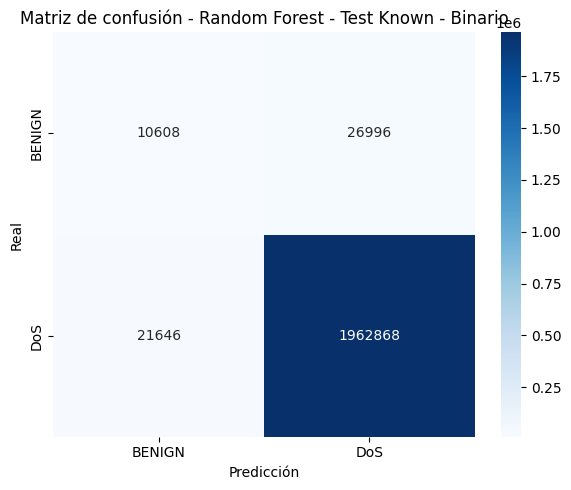


==== RANDOM FOREST - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9967,0.9984,98418.0000
accuracy,0.9967,0.9967,0.9967,0.9967
macro avg,0.5000,0.4984,0.4992,98418.0000
weighted avg,1.0000,0.9967,0.9984,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  320 98098]]

No se pudo calcular el area bajo la curva ROC


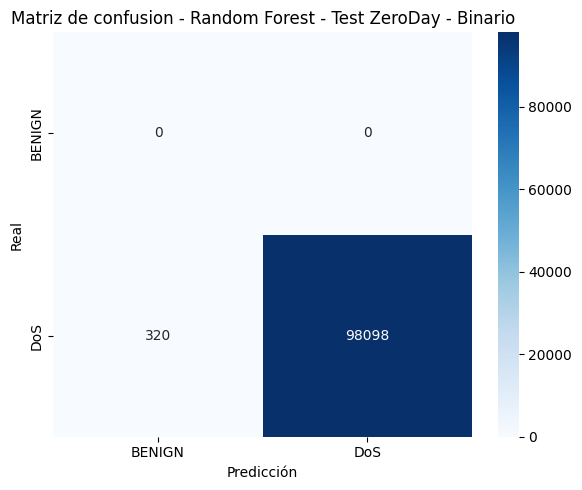

Tasa de detección de ataques ZeroDay - Binario: 0.9967


In [3]:
rf_pipe_binario = construccion_rf_pipeline(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=19)
rf_pipe_binario.fit(x_train_binario_undersampling, y_train_binario_undersampling)

# VALIDACION
print("\n==== RANDOM FOREST - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_rf,
    "roc_rf_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== RANDOM FOREST - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_rf,
    "roc_rf_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== RANDOM FOREST - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_rf, 
    "roc_rf_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

#### Clasificacion Multiclase


==== RANDOM FOREST - VALIDACION - MULTICLASE ====
Informe de clasificacion - Validacion - Multiclase:

              precision    recall  f1-score   support

      Benign       0.97      0.98      0.97      1929
        DDoS       0.96      0.90      0.93    496693
         DoS       0.71      0.86      0.78    144636
   Malformed       0.83      0.80      0.81       505
       Recon       0.96      0.97      0.97      8716
    Spoofing       0.78      0.77      0.77      1597

    accuracy                           0.89    654076
   macro avg       0.87      0.88      0.87    654076
weighted avg       0.90      0.89      0.90    654076



,precision,recall,f1-score,support
Benign,0.9691,0.9756,0.9724,1929.0000
DDoS,0.9563,0.9002,0.9274,496693.0000
DoS,0.7148,0.8587,0.7802,144636.0000
Malformed,0.8262,0.8000,0.8129,505.0000
Recon,0.9632,0.9668,0.9650,8716.0000
Spoofing,0.7778,0.7714,0.7746,1597.0000
accuracy,0.8918,0.8918,0.8918,0.8918
macro avg,0.8679,0.8788,0.8721,654076.0000
weighted avg,0.9025,0.8918,0.8950,654076.0000



Matriz de confusion - Validacion - Multiclase:

[[  1882     23     24      0      0      0]
 [    24 447142  49525      0      1      1]
 [    36  20396 124202      0      1      1]
 [     0      0      0    404     27     74]
 [     0      0      0     13   8427    276]
 [     0      0      0     72    293   1232]]

Area bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: 0.982

==== RANDOM FOREST - TEST KNOWN - MULTICLASE ====
Informe de clasificacion - Test Known - Multiclase:

              precision    recall  f1-score   support

      Benign       0.53      0.00      0.01     37604
        DDoS       0.93      0.76      0.84   1525492
         DoS       0.66      0.65      0.66    430423
   Malformed       0.01      0.78      0.02      1737
       Recon       0.12      0.98      0.22     20997
    Spoofing       0.04      0.47      0.08      5865

    accuracy                           0.72   2022118
   macro avg       0.38      0.61      0.30   2022118
weighted avg   

,precision,recall,f1-score,support
Benign,0.5294,0.0026,0.0052,37604.000
DDoS,0.9338,0.7581,0.8368,1525492.000
DoS,0.6633,0.6473,0.6552,430423.000
Malformed,0.0103,0.7795,0.0204,1737.000
Recon,0.1211,0.9812,0.2156,20997.000
Spoofing,0.0445,0.4730,0.0814,5865.000
accuracy,0.7220,0.7220,0.7220,0.722
macro avg,0.3837,0.6070,0.3024,2022118.000
weighted avg,0.8569,0.7220,0.7733,2022118.000



Matriz de confusion - Test Known - Multiclase:

[[     99       1       0    1952   13550   22002]
 [     84 1156467  141432  104966   99811   22732]
 [      4   82001  278606   22307   33243   14262]
 [      0       0       0    1354     168     215]
 [      0       0       0      52   20603     342]
 [      0      30       2     324    2735    2774]]

Area bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: 0.871


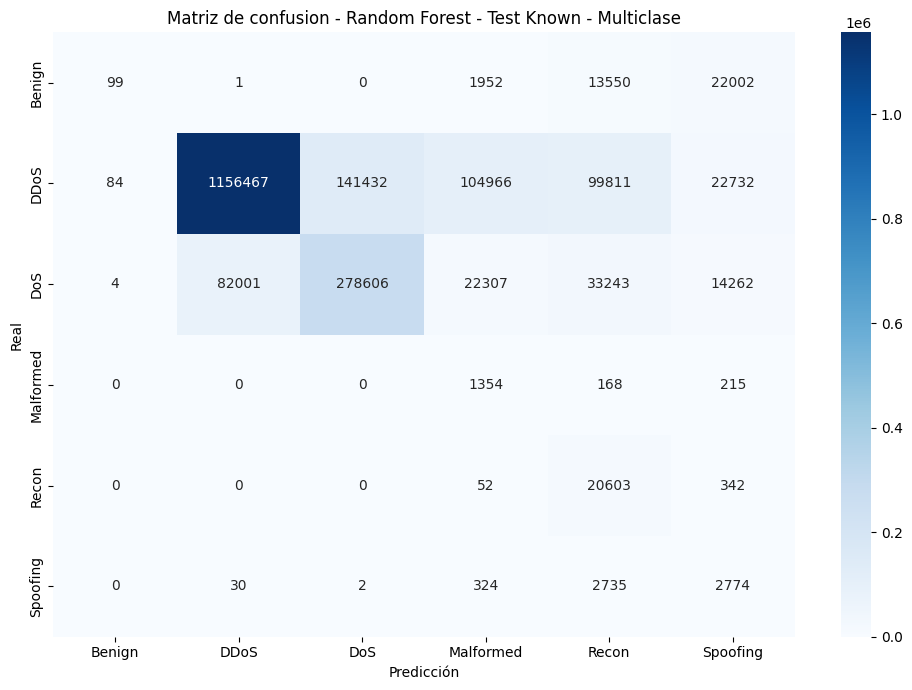


==== RANDOM FOREST - TEST ZERODAY - MULTICLASE ====
Informe de clasificacion - Test ZeroDay - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
        DDoS       0.00      0.00      0.00         0
         DoS       1.00      0.00      0.00     98418

    accuracy                           0.00     98418
   macro avg       0.33      0.00      0.00     98418
weighted avg       1.00      0.00      0.00     98418



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,0.0000
DDoS,0.0000,0.0000,0.0000,0.0000
DoS,1.0000,0.0006,0.0012,98418.0000
accuracy,0.0006,0.0006,0.0006,0.0006
macro avg,0.3333,0.0002,0.0004,98418.0000
weighted avg,1.0000,0.0006,0.0012,98418.0000



Matriz de confusion - Test ZeroDay - Multiclase:

[[    0     0     0]
 [    0     0     0]
 [  119 98242    57]]

No se pudo calcular el area bajo la curva ROC (AUC macro OvR)


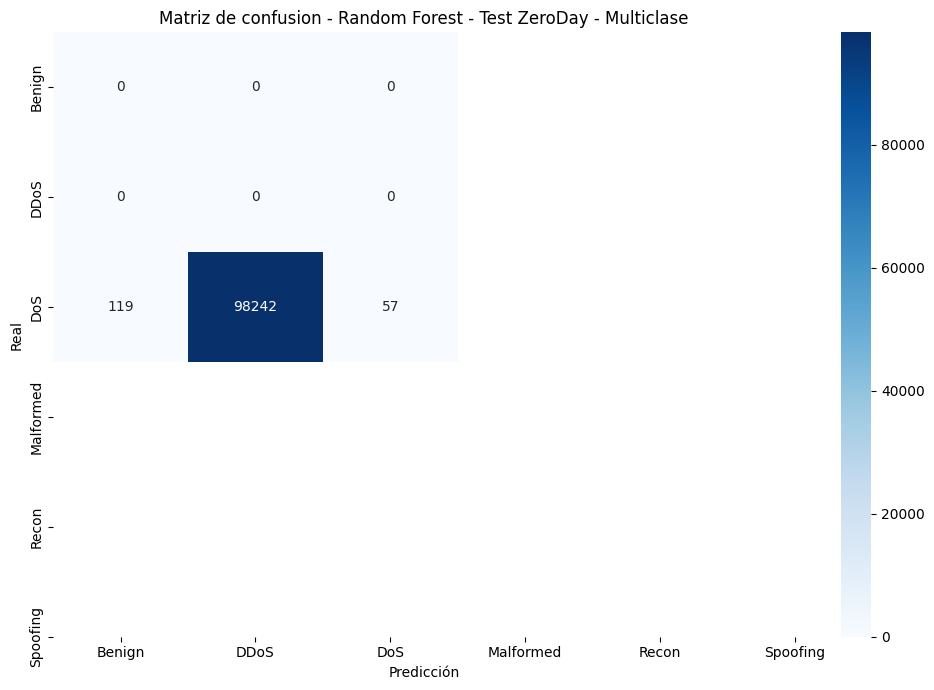

Tasa de detección de ataques ZeroDay (Multiclase): 0.9988


In [4]:
rf_pipe_multiclase = construccion_rf_pipeline(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=19)
rf_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase)
clases_multiclase = rf_pipe_multiclase.named_steps["rf"].classes_

# VALIDACION
print("\n==== RANDOM FOREST - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_rf_multiclase(
    rf_pipe_multiclase, 
    x_val_multiclase, 
    y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

if not np.isnan(auc_val_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_val_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

# TEST KNOWN
print("\n==== RANDOM FOREST - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_rf_multiclase(
    rf_pipe_multiclase, 
    x_test_known_multiclase, 
    y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

if not np.isnan(auc_test_known_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_test_known_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== RANDOM FOREST - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_rf_multiclase(
    rf_pipe_multiclase, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

if not np.isnan(auc_test_zeroday_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test ZeroDay - Multiclase: {auc_test_zeroday_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# Decision Tree

In [5]:
from Scripts_modelos_supervisados.decisiontree import construccion_dt_pipeline, evaluar_dt_binario, evaluar_dt_multiclase

carpeta_salida_dt = "Resultados/DecisionTree"
os.makedirs(carpeta_salida_dt, exist_ok=True)

#### Clasificacion Binaria


==== DECISION TREE - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.82      1.00      0.89    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.6428,0.9964,0.7815,1929.0000
1,1.0000,0.9984,0.9992,652147.0000
accuracy,0.9984,0.9984,0.9984,0.9984
macro avg,0.8214,0.9974,0.8903,654076.0000
weighted avg,0.9989,0.9984,0.9985,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1922      7]
 [  1068 651079]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 0.997

==== DECISION TREE - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.06      0.10      0.07     37604
           1       0.98      0.97      0.98   1984514

    accuracy                           0.95   2022118
   macro avg       0.52      0.53      0.53   2022118
weighted avg       0.97      0.95      0.96   2022118



,precision,recall,f1-score,support
0,0.0589,0.0979,0.0735,3.760400e+04
1,0.9827,0.9703,0.9765,1.984514e+06
accuracy,0.9541,0.9541,0.9541,9.541000e-01
macro avg,0.5208,0.5341,0.5250,2.022118e+06
weighted avg,0.9655,0.9541,0.9597,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[   3682   33922]
 [  58843 1925671]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.534


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

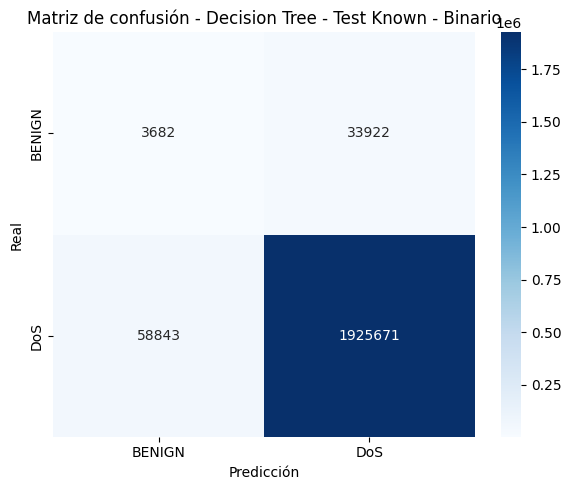


==== DECISION TREE - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.000,0.0000,0.0000,0.000
1,1.000,0.9970,0.9985,98418.000
accuracy,0.997,0.9970,0.9970,0.997
macro avg,0.500,0.4985,0.4993,98418.000
weighted avg,1.000,0.9970,0.9985,98418.000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  292 98126]]

No se pudo calcular el area bajo la curva ROC


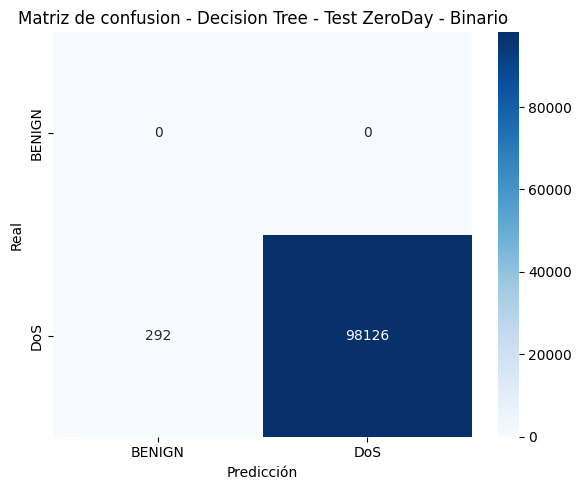

Tasa de detección de ataques ZeroDay - Binario: 0.9970


In [6]:
dt_pipe_binario = construccion_dt_pipeline(criterion="gini", max_depth=None, random_state=19)
dt_pipe_binario.fit(x_train_binario_undersampling, y_train_binario_undersampling)

# VALIDACION
print("\n==== DECISION TREE - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_dt_binario(
    dt_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_dt,
    "roc_dt_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== DECISION TREE - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_dt_binario(
    dt_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_dt,
    "roc_dt_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Decision Tree - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_dt, "matriz_confusion_dt_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== DECISION TREE - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_dt_binario(
    dt_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_dt, 
    "roc_dt_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Decision Tree - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_dt, "matriz_confusion_dt_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

#### Clasificacion Multiclase


==== DECISION TREE - VALIDACION - MULTICLASE ====
Informe de clasificacion - Validacion - Multiclase:

              precision    recall  f1-score   support

      Benign       0.96      0.95      0.96      1929
        DDoS       0.93      0.93      0.93    496693
         DoS       0.76      0.76      0.76    144636
   Malformed       0.78      0.78      0.78       505
       Recon       0.96      0.96      0.96      8716
    Spoofing       0.76      0.74      0.75      1597

    accuracy                           0.89    654076
   macro avg       0.86      0.85      0.86    654076
weighted avg       0.89      0.89      0.89    654076



,precision,recall,f1-score,support
Benign,0.9648,0.9523,0.9585,1929.0000
DDoS,0.9290,0.9298,0.9294,496693.0000
DoS,0.7581,0.7561,0.7571,144636.0000
Malformed,0.7809,0.7762,0.7786,505.0000
Recon,0.9581,0.9644,0.9612,8716.0000
Spoofing,0.7639,0.7414,0.7525,1597.0000
accuracy,0.8913,0.8913,0.8913,0.8913
macro avg,0.8591,0.8534,0.8562,654076.0000
weighted avg,0.8912,0.8913,0.8913,654076.0000



Matriz de confusion - Validacion - Multiclase:

[[  1837     44     48      0      0      0]
 [    31 461806  34848      0      6      2]
 [    36  35238 109358      1      1      2]
 [     0      0      1    392     32     80]
 [     0      0      2     26   8406    282]
 [     0      0      1     83    329   1184]]

Area bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: 0.918

==== DECISION TREE - TEST KNOWN - MULTICLASE ====
Informe de clasificacion - Test Known - Multiclase:

              precision    recall  f1-score   support

      Benign       0.94      0.07      0.14     37604
        DDoS       0.90      0.68      0.77   1525492
         DoS       0.71      0.56      0.62    430423
   Malformed       0.01      0.70      0.02      1737
       Recon       0.07      0.97      0.13     20997
    Spoofing       0.02      0.46      0.04      5865

    accuracy                           0.64   2022118
   macro avg       0.44      0.57      0.29   2022118
weighted avg   

,precision,recall,f1-score,support
Benign,0.9379,0.0731,0.1357,3.760400e+04
DDoS,0.8985,0.6767,0.7720,1.525492e+06
DoS,0.7072,0.5590,0.6244,4.304230e+05
Malformed,0.0093,0.7018,0.0184,1.737000e+03
Recon,0.0713,0.9679,0.1329,2.099700e+04
Spoofing,0.0235,0.4609,0.0448,5.865000e+03
accuracy,0.6429,0.6429,0.6429,6.429000e-01
macro avg,0.4413,0.5732,0.2880,2.022118e+06
weighted avg,0.8467,0.6429,0.7194,2.022118e+06



Matriz de confusion - Test Known - Multiclase:

[[   2750      17     420    2148   13372   18897]
 [    166 1032321   99097   99742  220165   74001]
 [     14  116371  240611   26474   28609   18344]
 [      0       4       0    1219     179     335]
 [      1      13      12     138   20322     511]
 [      1     158      96     724    2183    2703]]

Area bajo la curva ROC (AUC macro OvR) - Test Known - Multiclase: 0.743


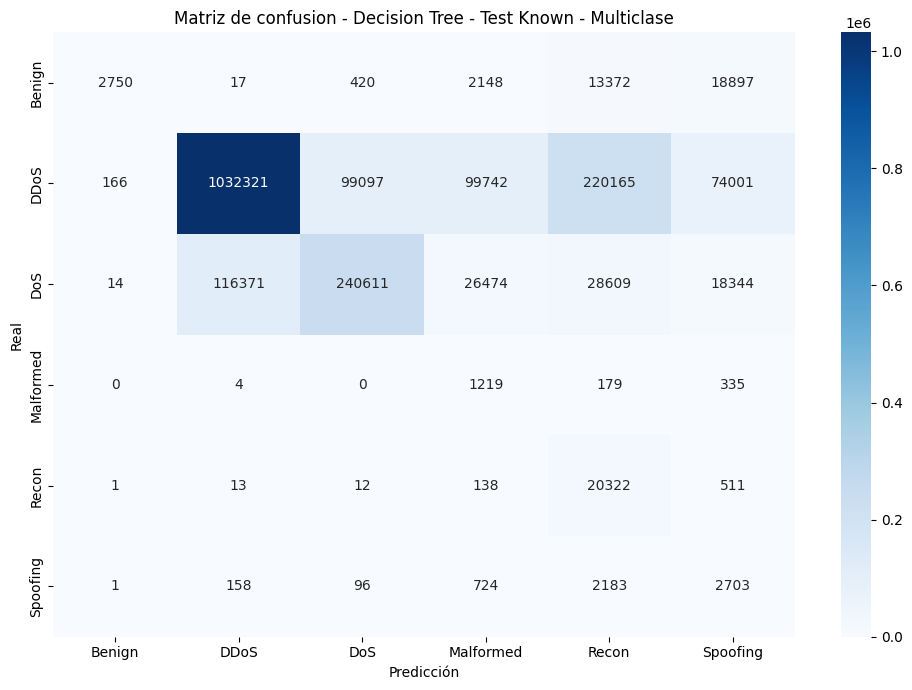


==== RANDOM FOREST - TEST ZERODAY - MULTICLASE ====
Informe de clasificacion - Test ZeroDay - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
        DDoS       0.00      0.00      0.00         0
         DoS       1.00      0.00      0.00     98418

    accuracy                           0.00     98418
   macro avg       0.33      0.00      0.00     98418
weighted avg       1.00      0.00      0.00     98418



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,0.0000
DDoS,0.0000,0.0000,0.0000,0.0000
DoS,1.0000,0.0008,0.0016,98418.0000
accuracy,0.0008,0.0008,0.0008,0.0008
macro avg,0.3333,0.0003,0.0005,98418.0000
weighted avg,1.0000,0.0008,0.0016,98418.0000



Matriz de confusion - Test ZeroDay - Multiclase:

[[    0     0     0]
 [    0     0     0]
 [  115 98226    77]]

No se pudo calcular el area bajo la curva ROC (AUC macro OvR)


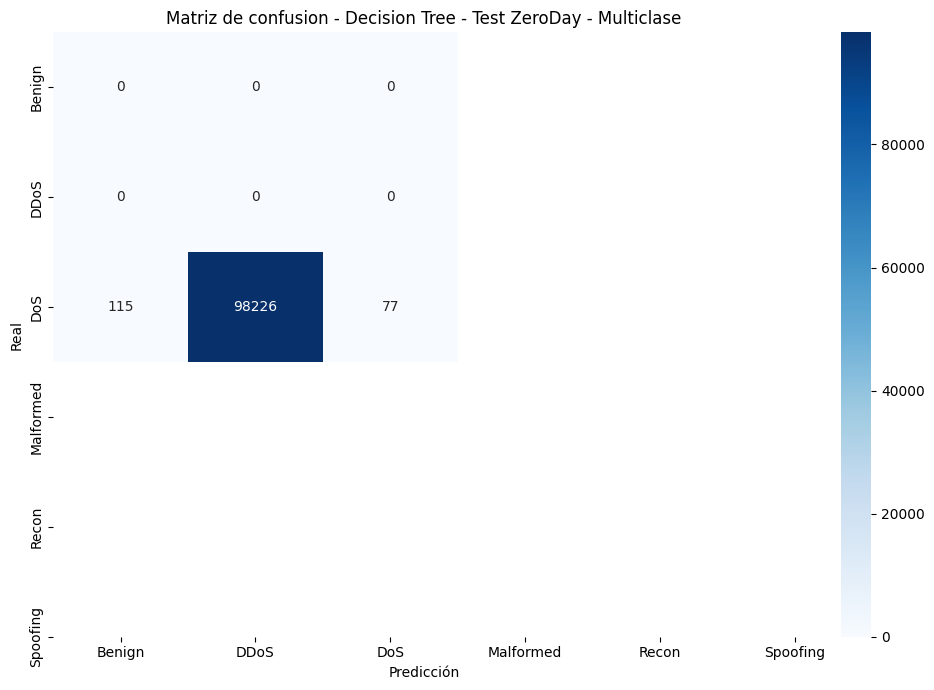

Tasa de detección de ataques ZeroDay (Multiclase): 0.9988


In [7]:
dt_pipe_multiclase = construccion_dt_pipeline(criterion="gini", max_depth=None, random_state=19)
dt_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase)
clases_multiclase = dt_pipe_multiclase.named_steps["dt"].classes_

print("\n==== DECISION TREE - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_dt_multiclase(
    dt_pipe_multiclase, 
    x_val_multiclase, 
    y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

if not np.isnan(auc_val_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_val_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

# TEST KNOWN
print("\n==== DECISION TREE - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_dt_multiclase(
    dt_pipe_multiclase, 
    x_test_known_multiclase, 
    y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

if not np.isnan(auc_test_known_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test Known - Multiclase: {auc_test_known_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Decision Tree - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_dt}/matriz_confusion_dt_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== RANDOM FOREST - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_dt_multiclase(
    dt_pipe_multiclase, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

if not np.isnan(auc_test_zeroday_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test ZeroDay - Multiclase: {auc_test_zeroday_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Decision Tree - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_dt}/matriz_confusion_dt_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# Support Vector Machine

In [2]:
from Scripts_modelos_supervisados.supportvectormachine import construccion_svm_pipeline_binario, construccion_svm_pipeline_multiclase, evaluar_svm_binario, evaluar_svm_multiclase

carpeta_salida_svm = "Resultados/SupportVectorMachine"
os.makedirs(carpeta_salida_svm, exist_ok=True)

#### Clasificacion Binaria


==== SUPPORT VECTOR MACHINE - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.75      1.00      0.83    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.4997,0.9995,0.6663,1929.000
1,1.0000,0.9970,0.9985,652147.000
accuracy,0.9970,0.9970,0.9970,0.997
macro avg,0.7499,0.9983,0.8324,654076.000
weighted avg,0.9985,0.9970,0.9975,654076.000



 Matriz de confusion - Validacion - Binario:

[[  1928      1]
 [  1930 650217]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 1.000

==== SUPPORT VECTOR MACHINE - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.03      0.18      0.05     37604
           1       0.98      0.89      0.93   1984514

    accuracy                           0.88   2022118
   macro avg       0.51      0.54      0.49   2022118
weighted avg       0.97      0.88      0.92   2022118



,precision,recall,f1-score,support
0,0.0311,0.1843,0.0533,3.760400e+04
1,0.9830,0.8913,0.9349,1.984514e+06
accuracy,0.8782,0.8782,0.8782,8.782000e-01
macro avg,0.5070,0.5378,0.4941,2.022118e+06
weighted avg,0.9653,0.8782,0.9185,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[   6929   30675]
 [ 215651 1768863]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.814


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

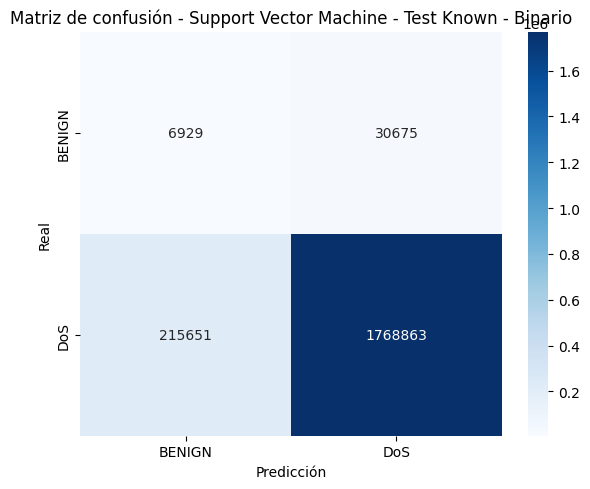


==== SUPPORT VECTOR MACHINE - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9958,0.9979,98418.0000
accuracy,0.9958,0.9958,0.9958,0.9958
macro avg,0.5000,0.4979,0.4989,98418.0000
weighted avg,1.0000,0.9958,0.9979,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  413 98005]]

No se pudo calcular el area bajo la curva ROC


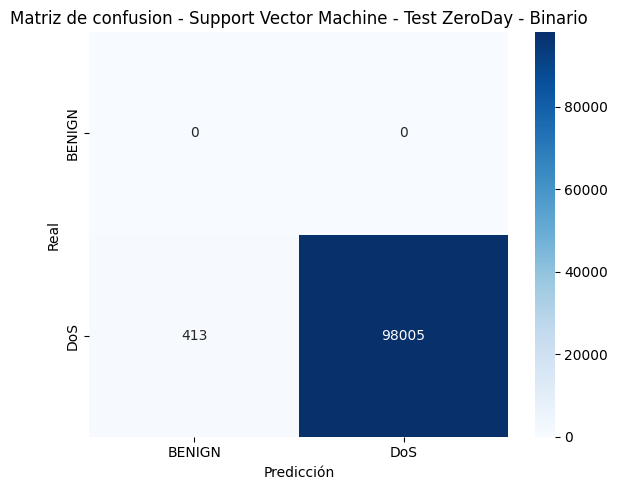

Tasa de detección de ataques ZeroDay - Binario: 0.9958


In [ ]:
svm_pipe_binario = construccion_svm_pipeline_binario(kernel = 'rbf', C = 1.0, gamma = 'scale', random_state = 19, class_weight="balanced")
svm_pipe_binario.fit(x_train_binario_undersampling, y_train_binario_undersampling)

# VALIDACION
print("\n==== SUPPORT VECTOR MACHINE - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_svm_binario(
    svm_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_dt,
    "roc_dt_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== SUPPORT VECTOR MACHINE - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_svm_binario(
    svm_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_dt,
    "roc_dt_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Support Vector Machine - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_svm, "matriz_confusion_svm_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== SUPPORT VECTOR MACHINE - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_svm_binario(
    svm_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_dt, 
    "roc_svm_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Support Vector Machine - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_svm, "matriz_confusion_svm_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

#### Clasificacion Multiclase

(294333, 38)
Attack_family
DDoS         223511
DoS           65086
Recon          3922
Benign          868
Spoofing        719
Malformed       227
Name: count, dtype: int64

==== SUPPORT VECTOR MACHINE - VALIDACION - MULTICLASE ====
Informe de clasificacion - Validacion - Multiclase:

              precision    recall  f1-score   support

      Benign       0.58      0.98      0.73      1929
        DDoS       0.98      0.86      0.91    496693
         DoS       0.65      0.92      0.76    144636
   Malformed       0.48      0.72      0.58       505
       Recon       0.98      0.92      0.95      8716
    Spoofing       0.60      0.76      0.67      1597

    accuracy                           0.87    654076
   macro avg       0.71      0.86      0.77    654076
weighted avg       0.90      0.87      0.88    654076



,precision,recall,f1-score,support
Benign,0.5827,0.9751,0.7295,1929.0000
DDoS,0.9757,0.8559,0.9119,496693.0000
DoS,0.6514,0.9196,0.7626,144636.0000
Malformed,0.4784,0.7248,0.5764,505.0000
Recon,0.9799,0.9189,0.9484,8716.0000
Spoofing,0.6036,0.7646,0.6746,1597.0000
accuracy,0.8709,0.8709,0.8709,0.8709
macro avg,0.7120,0.8598,0.7672,654076.0000
weighted avg,0.9016,0.8709,0.8780,654076.0000



Matriz de confusion - Validacion - Multiclase:

[[  1881      1     47      0      0      0]
 [   327 425126  71133      5     16     86]
 [  1018  10554 133010      0     12     42]
 [     0      0      0    366     45     94]
 [     1     15      0    111   8009    580]
 [     1      1      0    283     91   1221]]

==== SUPPORT VECTOR MACHINE - TEST KNOWN - MULTICLASE ====
Informe de clasificacion - Test Known - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00     37604
        DDoS       0.97      0.63      0.77   1525492
         DoS       0.69      0.67      0.68    430423
   Malformed       0.00      0.00      0.00      1737
       Recon       0.09      0.88      0.17     20997
    Spoofing       0.02      0.99      0.03      5865

    accuracy                           0.63   2022118
   macro avg       0.29      0.53      0.27   2022118
weighted avg       0.88      0.63      0.72   2022118



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,3.760400e+04
DDoS,0.9688,0.6345,0.7668,1.525492e+06
DoS,0.6890,0.6689,0.6788,4.304230e+05
Malformed,0.0000,0.0000,0.0000,1.737000e+03
Recon,0.0940,0.8793,0.1698,2.099700e+04
Spoofing,0.0151,0.9937,0.0297,5.865000e+03
accuracy,0.6331,0.6331,0.6331,6.331000e-01
macro avg,0.2945,0.5294,0.2742,2.022118e+06
weighted avg,0.8785,0.6331,0.7248,2.022118e+06



Matriz de confusion - Test Known - Multiclase:

[[     0      0      0      1     15  37588]
 [   878 967891 129935  21210 157039 248539]
 [    55  31019 287926     33  20872  90518]
 [     0      0      0      0     93   1644]
 [     0    197      0      0  18462   2338]
 [    21      3      0      3     10   5828]]


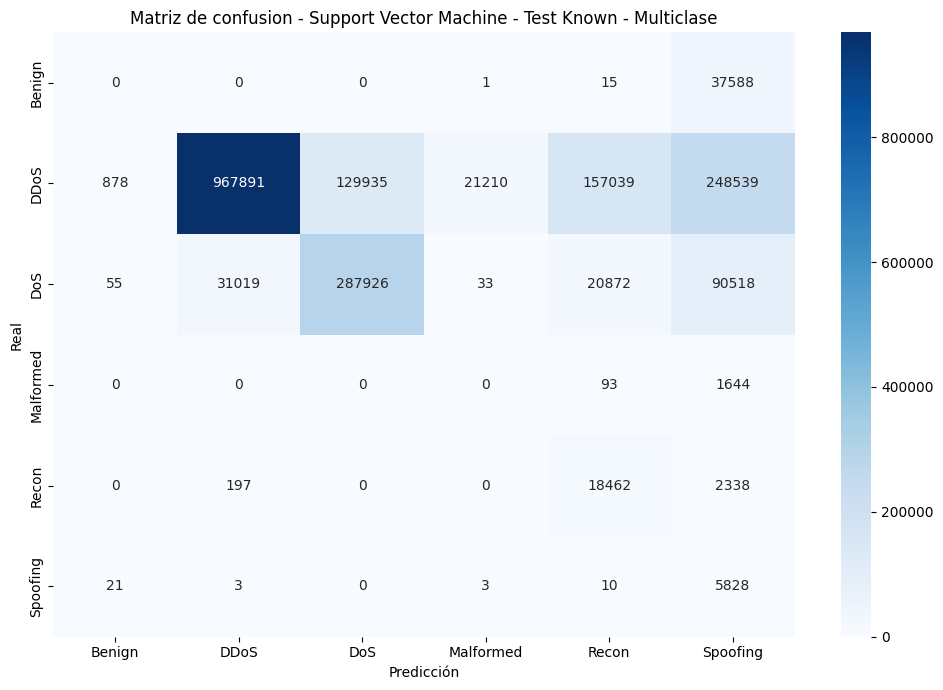


==== SUPPORT VECTOR MACHINE - TEST ZERODAY - MULTICLASE ====
Informe de clasificacion - Test ZeroDay - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
        DDoS       0.00      0.00      0.00         0
         DoS       1.00      0.00      0.00     98418
       Recon       0.00      0.00      0.00         0
    Spoofing       0.00      0.00      0.00         0

    accuracy                           0.00     98418
   macro avg       0.20      0.00      0.00     98418
weighted avg       1.00      0.00      0.00     98418



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,0.0000
DDoS,0.0000,0.0000,0.0000,0.0000
DoS,1.0000,0.0001,0.0002,98418.0000
Recon,0.0000,0.0000,0.0000,0.0000
Spoofing,0.0000,0.0000,0.0000,0.0000
accuracy,0.0001,0.0001,0.0001,0.0001
macro avg,0.2000,0.0000,0.0000,98418.0000
weighted avg,1.0000,0.0001,0.0002,98418.0000



Matriz de confusion - Test ZeroDay - Multiclase:

[[    0     0     0     0     0]
 [    0     0     0     0     0]
 [  235 98152    11    11     9]
 [    0     0     0     0     0]
 [    0     0     0     0     0]]


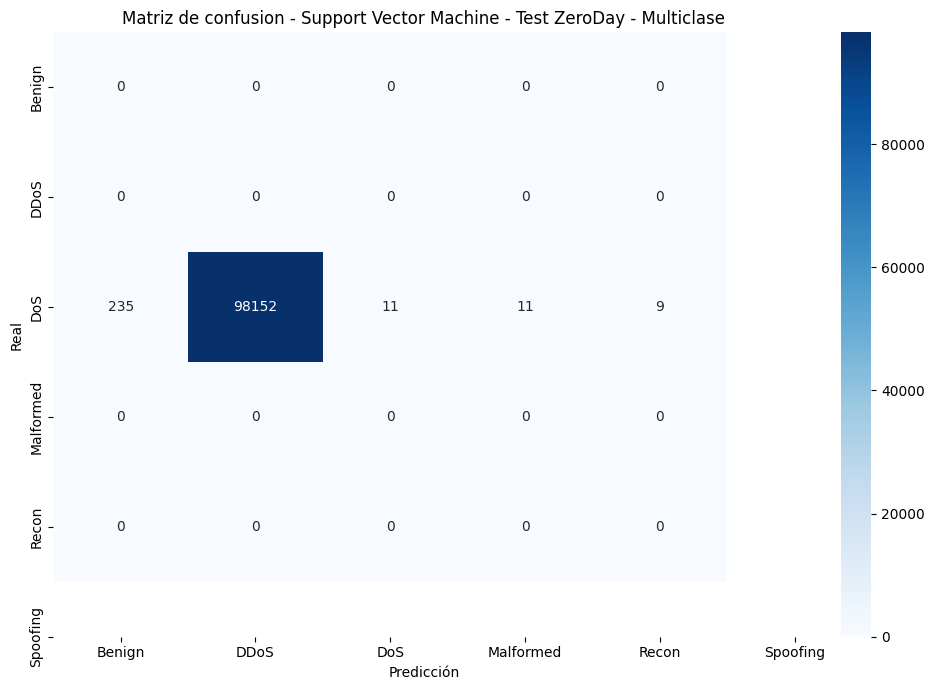

Tasa de detección de ataques ZeroDay (Multiclase): 0.9976


In [3]:
indices_svm_multiclase= (y_train_multiclase.groupby(y_train_multiclase).sample(frac=0.05, random_state=19).index)

x_train_multiclase_svm = x_train_multiclase.loc[indices_svm_multiclase]
y_train_multiclase_svm = y_train_multiclase.loc[indices_svm_multiclase]

print(x_train_multiclase_svm.shape)
print(y_train_multiclase_svm.value_counts())

#svm_pipe_multiclase = construccion_svm_pipeline_binario(kernel = 'rbf', C = 1.0, gamma = 'scale', random_state = 19, class_weight="balanced")
svm_pipe_multiclase_LinearSVC = construccion_svm_pipeline_multiclase(C = 1.0, random_state = 19, class_weight="balanced", max_iter= 20000)
svm_pipe_multiclase_LinearSVC.fit(x_train_multiclase_svm, y_train_multiclase_svm)
clases_multiclase = svm_pipe_multiclase_LinearSVC.named_steps["svm"].classes_

print("\n==== SUPPORT VECTOR MACHINE - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase = evaluar_svm_multiclase(
    svm_pipe_multiclase_LinearSVC, 
    x_val_multiclase, 
    y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

# TEST KNOWN
print("\n==== SUPPORT VECTOR MACHINE - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase = evaluar_svm_multiclase(
    svm_pipe_multiclase_LinearSVC, 
    x_test_known_multiclase, 
    y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Support Vector Machine - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_svm}/matriz_confusion_svm_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== SUPPORT VECTOR MACHINE - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase = evaluar_svm_multiclase(
    svm_pipe_multiclase_LinearSVC, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Support Vector Machine - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_svm}/matriz_confusion_svm_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# Naive Bayes

In [2]:
from Scripts_modelos_supervisados.naivebayes import construccion_nb_pipeline, evaluar_nb_binario, evaluar_nb_multiclase

carpeta_salida_nb = "Resultados/NaiveBayes"
os.makedirs(carpeta_salida_nb, exist_ok=True)

#### Clasificacion Binaria


==== NAIVE BAYES - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.20      1.00      0.33      1929
           1       1.00      0.99      0.99    652147

    accuracy                           0.99    654076
   macro avg       0.60      0.99      0.66    654076
weighted avg       1.00      0.99      0.99    654076



,precision,recall,f1-score,support
0,0.2004,0.9969,0.3338,1929.0000
1,1.0000,0.9882,0.9941,652147.0000
accuracy,0.9883,0.9883,0.9883,0.9883
macro avg,0.6002,0.9926,0.6639,654076.0000
weighted avg,0.9976,0.9883,0.9921,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1923      6]
 [  7671 644476]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 0.997

==== NAIVE BAYES - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.40      0.47      0.44     37604
           1       0.99      0.99      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.70      0.73      0.71   2022118
weighted avg       0.98      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.4036,0.4723,0.4352,3.760400e+04
1,0.9900,0.9868,0.9884,1.984514e+06
accuracy,0.9772,0.9772,0.9772,9.772000e-01
macro avg,0.6968,0.7296,0.7118,2.022118e+06
weighted avg,0.9791,0.9772,0.9781,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[  17762   19842]
 [  26252 1958262]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.731


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

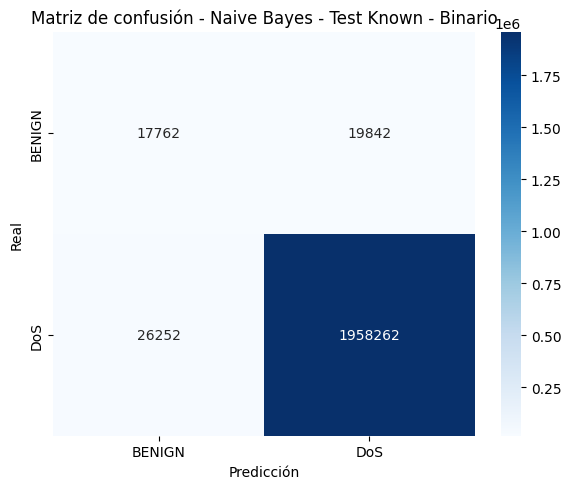


==== NAIVE BAYES - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9973,0.9986,98418.0000
accuracy,0.9973,0.9973,0.9973,0.9973
macro avg,0.5000,0.4986,0.4993,98418.0000
weighted avg,1.0000,0.9973,0.9986,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  267 98151]]

No se pudo calcular el area bajo la curva ROC


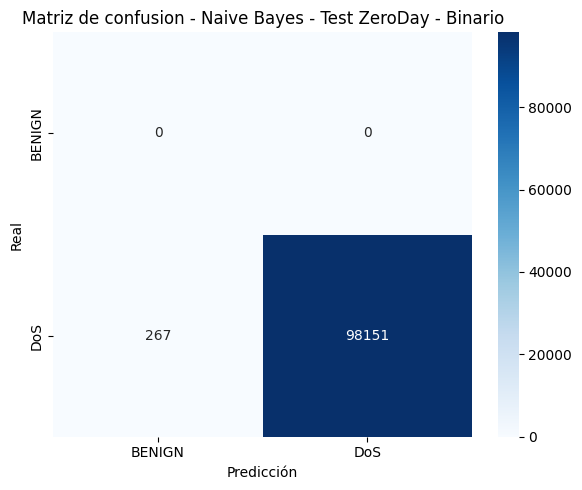

Tasa de detección de ataques ZeroDay - Binario: 0.9973


In [8]:
nb_pipe_binario = construccion_nb_pipeline()
nb_pipe_binario.fit(x_train_binario_undersampling, y_train_binario_undersampling)

print("\n==== NAIVE BAYES - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_nb_binario(
    nb_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_nb,
    "roc_nb_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== NAIVE BAYES - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_nb_binario(
    nb_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_nb,
    "roc_nb_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Naive Bayes - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_nb, "matriz_confusion_nb_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== NAIVE BAYES - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_nb_binario(
    nb_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_nb, 
    "roc_nb_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Naive Bayes - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_nb, "matriz_confusion_nb_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")



#### Clasificacion Multiclase


==== NAIVE BAYES - VALIDACION - MULTICLASE ====
Informe de clasificacion - Validacion - Multiclase:

              precision    recall  f1-score   support

      Benign       0.23      1.00      0.38      1929
        DDoS       0.80      0.95      0.86    496693
         DoS       0.42      0.13      0.19    144636
   Malformed       0.30      0.93      0.46       505
       Recon       0.99      0.88      0.93      8716
    Spoofing       0.58      0.62      0.60      1597

    accuracy                           0.76    654076
   macro avg       0.55      0.75      0.57    654076
weighted avg       0.71      0.76      0.71    654076



,precision,recall,f1-score,support
Benign,0.2326,0.9953,0.3770,1929.0000
DDoS,0.7952,0.9474,0.8647,496693.0000
DoS,0.4210,0.1252,0.1930,144636.0000
Malformed,0.3042,0.9307,0.4585,505.0000
Recon,0.9897,0.8835,0.9336,8716.0000
Spoofing,0.5803,0.6174,0.5983,1597.0000
accuracy,0.7641,0.7641,0.7641,0.7641
macro avg,0.5538,0.7499,0.5709,654076.0000
weighted avg,0.7125,0.7641,0.7146,654076.0000



Matriz de confusion - Validacion - Multiclase:

[[  1920      0      9      0      0      0]
 [  1082 470575  24897     12     51     76]
 [  5252 121206  18108      0     27     43]
 [     0      0      0    470      0     35]
 [     2      0      0    454   7701    559]
 [     0      0      0    609      2    986]]

Area bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: 0.936

==== NAIVE BAYES - TEST KNOWN - MULTICLASE ====
Informe de clasificacion - Test Known - Multiclase:

              precision    recall  f1-score   support

      Benign       0.11      1.00      0.20     37604
        DDoS       0.82      0.77      0.79   1525492
         DoS       0.32      0.18      0.23    430423
   Malformed       0.00      0.00      0.00      1737
       Recon       0.00      0.00      0.00     20997
    Spoofing       0.00      0.00      0.00      5865

    accuracy                           0.64   2022118
   macro avg       0.21      0.33      0.20   2022118
weighted avg     

,precision,recall,f1-score,support
Benign,0.1107,0.9983,0.1993,3.760400e+04
DDoS,0.8177,0.7708,0.7935,1.525492e+06
DoS,0.3228,0.1838,0.2342,4.304230e+05
Malformed,0.0000,0.0000,0.0000,1.737000e+03
Recon,0.0000,0.0000,0.0000,2.099700e+04
Spoofing,0.0000,0.0000,0.0000,5.865000e+03
accuracy,0.6391,0.6391,0.6391,6.391000e-01
macro avg,0.2085,0.3255,0.2045,2.022118e+06
weighted avg,0.6876,0.6391,0.6522,2.022118e+06



Matriz de confusion - Test Known - Multiclase:

[[  37541       2      61       0       0       0]
 [ 201055 1175780  148657       0       0       0]
 [  90379  260949   79095       0       0       0]
 [   1726       1      10       0       0       0]
 [   2837    1195   16965       0       0       0]
 [   5646       4     215       0       0       0]]

Area bajo la curva ROC (AUC macro OvR) - Test Known - Multiclase: 0.644


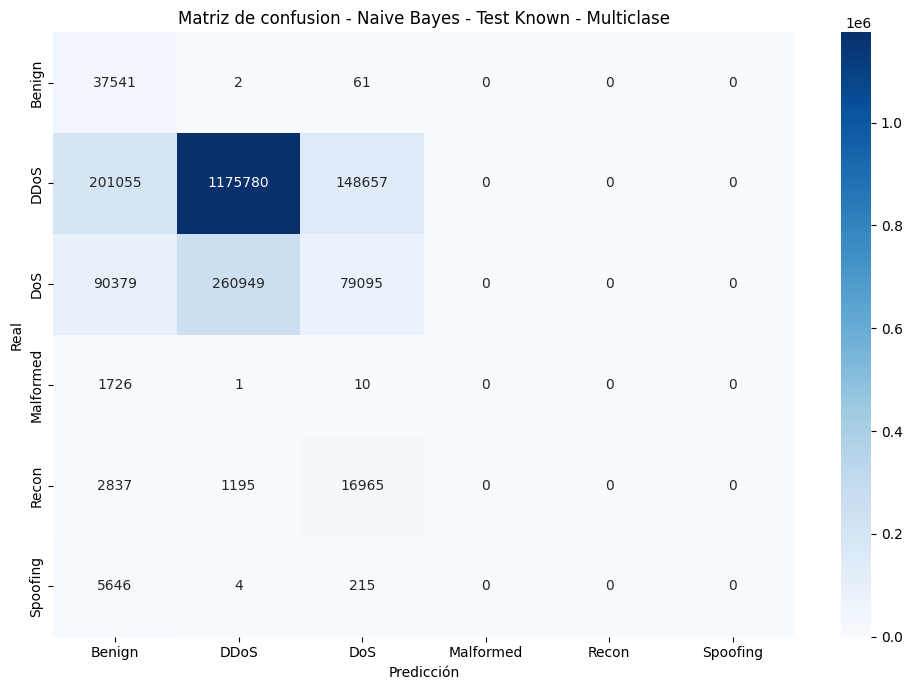


==== NAIVE BAYES - TEST ZERODAY - MULTICLASE ====
Informe de clasificacion - Test ZeroDay - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
        DDoS       0.00      0.00      0.00         0
         DoS       1.00      0.00      0.01     98418

    accuracy                           0.00     98418
   macro avg       0.33      0.00      0.00     98418
weighted avg       1.00      0.00      0.01     98418



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,0.0000
DDoS,0.0000,0.0000,0.0000,0.0000
DoS,1.0000,0.0026,0.0051,98418.0000
accuracy,0.0026,0.0026,0.0026,0.0026
macro avg,0.3333,0.0009,0.0017,98418.0000
weighted avg,1.0000,0.0026,0.0051,98418.0000



Matriz de confusion - Test ZeroDay - Multiclase:

[[    0     0     0]
 [    0     0     0]
 [  232 97935   251]]

No se pudo calcular el area bajo la curva ROC (AUC macro OvR)


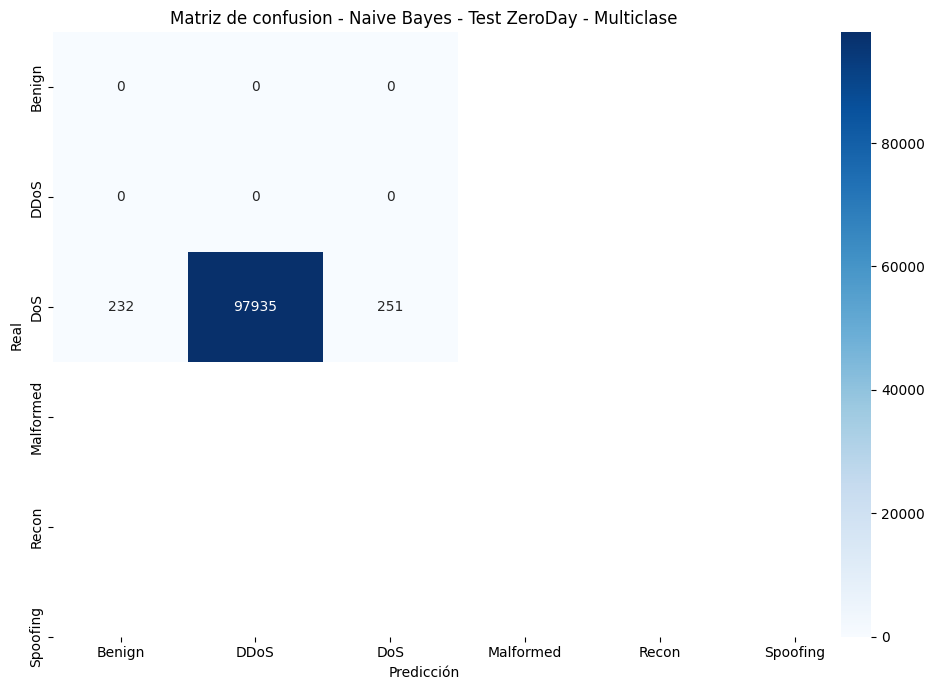

Tasa de detección de ataques ZeroDay (Multiclase): 0.9976


In [3]:
nb_pipe_multiclase = construccion_nb_pipeline()
nb_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase)
clases_multiclase = nb_pipe_multiclase.named_steps["nb"].classes_

print("\n==== NAIVE BAYES - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_nb_multiclase(
    nb_pipe_multiclase, 
    x_val_multiclase, 
    y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

if not np.isnan(auc_val_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_val_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

# TEST KNOWN
print("\n==== NAIVE BAYES - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_nb_multiclase(
    nb_pipe_multiclase, 
    x_test_known_multiclase, 
    y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

if not np.isnan(auc_test_known_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test Known - Multiclase: {auc_test_known_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Naive Bayes - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_nb}/matriz_confusion_nb_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== NAIVE BAYES - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_nb_multiclase(
    nb_pipe_multiclase, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

if not np.isnan(auc_test_zeroday_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test ZeroDay - Multiclase: {auc_test_zeroday_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Naive Bayes - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_nb}/matriz_confusion_nb_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# LightGBM

In [3]:
from Scripts_modelos_supervisados.LightGBM import construccion_lgbm_pipeline_binario, construccion_lgbm_pipeline_multiclase, evaluar_lgbm_binario, evaluar_lgbm_multiclase

carpeta_salida_lgbm = "Resultados/LightGBM"
os.makedirs(carpeta_salida_lgbm, exist_ok= True)

#### Clasificacion Binaria


==== LIGHT GBM - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.76      1.00      0.86      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.88      1.00      0.93    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.7586,1.0000,0.8627,1929.0000
1,1.0000,0.9991,0.9995,652147.0000
accuracy,0.9991,0.9991,0.9991,0.9991
macro avg,0.8793,0.9995,0.9311,654076.0000
weighted avg,0.9993,0.9991,0.9991,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1929      0]
 [   614 651533]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 1.000

==== LIGHT GBM - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.73      0.10      0.17     37604
           1       0.98      1.00      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.86      0.55      0.58   2022118
weighted avg       0.98      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.7312,0.0975,0.1720,3.760400e+04
1,0.9832,0.9993,0.9912,1.984514e+06
accuracy,0.9825,0.9825,0.9825,9.825000e-01
macro avg,0.8572,0.5484,0.5816,2.022118e+06
weighted avg,0.9785,0.9825,0.9759,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[   3665   33939]
 [   1347 1983167]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.977


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

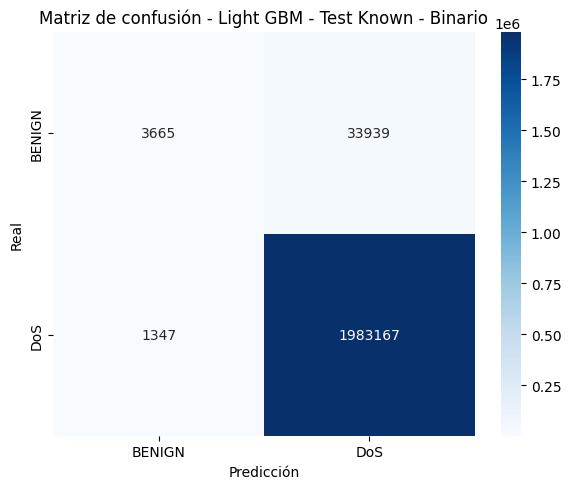


==== LIGHT GBM - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.000,0.0000,0.0000,0.000
1,1.000,0.9970,0.9985,98418.000
accuracy,0.997,0.9970,0.9970,0.997
macro avg,0.500,0.4985,0.4992,98418.000
weighted avg,1.000,0.9970,0.9985,98418.000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  299 98119]]

No se pudo calcular el area bajo la curva ROC


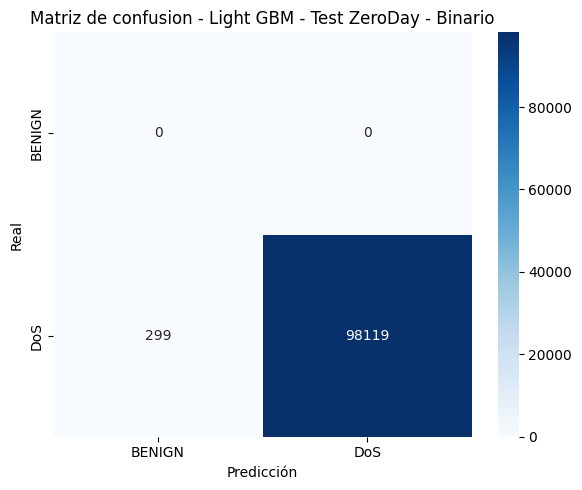

Tasa de detección de ataques ZeroDay - Binario: 0.9970


In [4]:
lgbm_pipe_binario = construccion_lgbm_pipeline_binario(objective="binary",n_estimators = 400, num_leaves = 64, learning_rate = 0.05, subsample = 0.9, colsample_bytree = 0.9, random_state = 19, n_jobs=-1, verbose=-1)
lgbm_pipe_binario.fit(x_train_binario_undersampling, y_train_binario_undersampling)

print("\n==== LIGHT GBM - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_lgbm_binario(
    lgbm_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_lgbm,
    "roc_lgbm_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== LIGHT GBM - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_lgbm_binario(
    lgbm_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_lgbm,
    "roc_lgbm_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Light GBM - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_lgbm, "matriz_confusion_lgbm_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== LIGHT GBM - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_lgbm_binario(
    lgbm_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_lgbm, 
    "roc_lgbm_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Light GBM - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_lgbm, "matriz_confusion_lgbm_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")



#### Clasificacion Multiclase


==== LIGHT GBM - VALIDACION - MULTICLASE ====
Informe de clasificacion - Validacion - Multiclase:

              precision    recall  f1-score   support

      Benign       0.91      0.89      0.90      1929
        DDoS       0.88      0.93      0.91    496693
         DoS       0.73      0.52      0.61    144636
   Malformed       0.48      0.36      0.41       505
       Recon       0.89      0.90      0.89      8716
    Spoofing       0.07      0.49      0.12      1597

    accuracy                           0.84    654076
   macro avg       0.66      0.68      0.64    654076
weighted avg       0.84      0.84      0.84    654076



,precision,recall,f1-score,support
0,0.7586,1.0000,0.8627,1929.0000
1,1.0000,0.9991,0.9995,652147.0000
accuracy,0.9991,0.9991,0.9991,0.9991
macro avg,0.8793,0.9995,0.9311,654076.0000
weighted avg,0.9993,0.9991,0.9991,654076.0000



Matriz de confusion - Validacion - Multiclase:

[[  1719     67     99      0      0     44]
 [    63 464317  27320      0    158   4835]
 [   104  63192  75685      0    216   5439]
 [     0     30     51    184    170     70]
 [     0    133    348     42   7833    360]
 [     0     43    185    158    428    783]]

Area bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: 0.801

==== LIGHT GBM - TEST KNOWN - MULTICLASE ====
Informe de clasificacion - Test Known - Multiclase:

              precision    recall  f1-score   support

      Benign       0.81      0.05      0.09     37604
        DDoS       0.87      0.80      0.83   1525492
         DoS       0.55      0.40      0.46    430423
   Malformed       0.01      0.23      0.02      1737
       Recon       0.10      0.89      0.18     20997
    Spoofing       0.03      0.41      0.06      5865

    accuracy                           0.70   2022118
   macro avg       0.39      0.46      0.27   2022118
weighted avg       

,precision,recall,f1-score,support
Benign,0.8102,0.0502,0.0945,3.760400e+04
DDoS,0.8651,0.8016,0.8322,1.525492e+06
DoS,0.5462,0.3958,0.4590,4.304230e+05
Malformed,0.0100,0.2268,0.0192,1.737000e+03
Recon,0.1008,0.8888,0.1811,2.099700e+04
Spoofing,0.0343,0.4102,0.0634,5.865000e+03
accuracy,0.7005,0.7005,0.7005,7.005000e-01
macro avg,0.3945,0.4622,0.2749,2.022118e+06
weighted avg,0.7851,0.7005,0.7293,2.022118e+06



Matriz de confusion - Test Known - Multiclase:

[[   1887    3546    2655     468   20003    9045]
 [    381 1222866  136405   33304  108087   24449]
 [     45  186153  170344    4794   35976   33111]
 [      0     124     235     394     792     192]
 [      3     398    1052       1   18663     880]
 [     13     411    1178     285    1572    2406]]

Area bajo la curva ROC (AUC macro OvR) - Test Known - Multiclase: 0.678


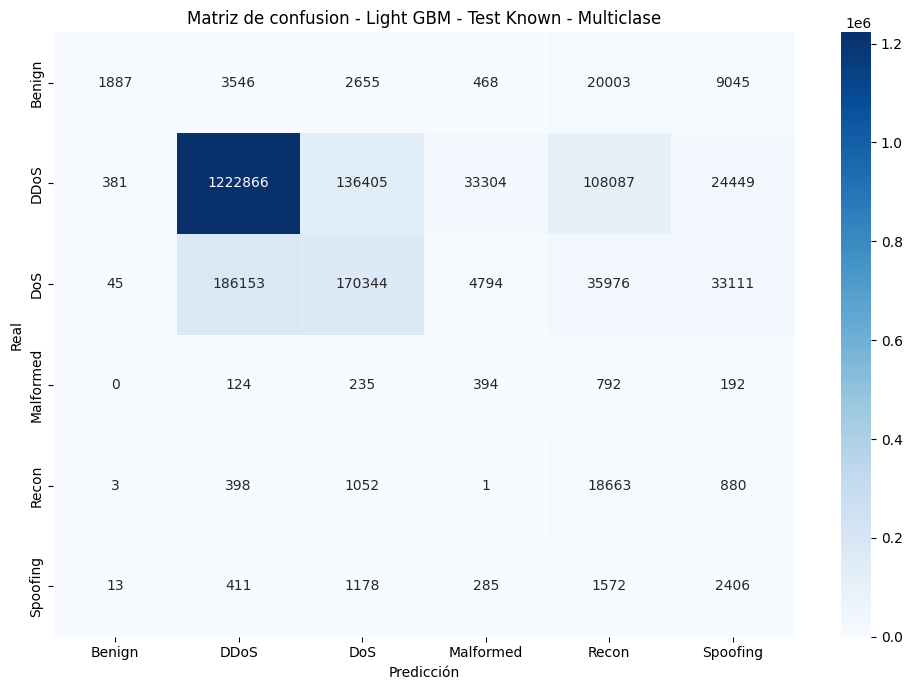


==== LIGHT GBM - TEST ZERODAY - MULTICLASE ====
Informe de clasificacion - Test ZeroDay - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
        DDoS       0.00      0.00      0.00         0
         DoS       1.00      0.00      0.00     98418
   Malformed       0.00      0.00      0.00         0
       Recon       0.00      0.00      0.00         0
    Spoofing       0.00      0.00      0.00         0

    accuracy                           0.00     98418
   macro avg       0.17      0.00      0.00     98418
weighted avg       1.00      0.00      0.00     98418



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,0.0000
DDoS,0.0000,0.0000,0.0000,0.0000
DoS,1.0000,0.0007,0.0013,98418.0000
Malformed,0.0000,0.0000,0.0000,0.0000
Recon,0.0000,0.0000,0.0000,0.0000
Spoofing,0.0000,0.0000,0.0000,0.0000
accuracy,0.0007,0.0007,0.0007,0.0007
macro avg,0.1667,0.0001,0.0002,98418.0000
weighted avg,1.0000,0.0007,0.0013,98418.0000



Matriz de confusion - Test ZeroDay - Multiclase:

[[    0     0     0     0     0     0]
 [    0     0     0     0     0     0]
 [  164 98169    64     1     3    17]
 [    0     0     0     0     0     0]
 [    0     0     0     0     0     0]
 [    0     0     0     0     0     0]]

No se pudo calcular el area bajo la curva ROC (AUC macro OvR)


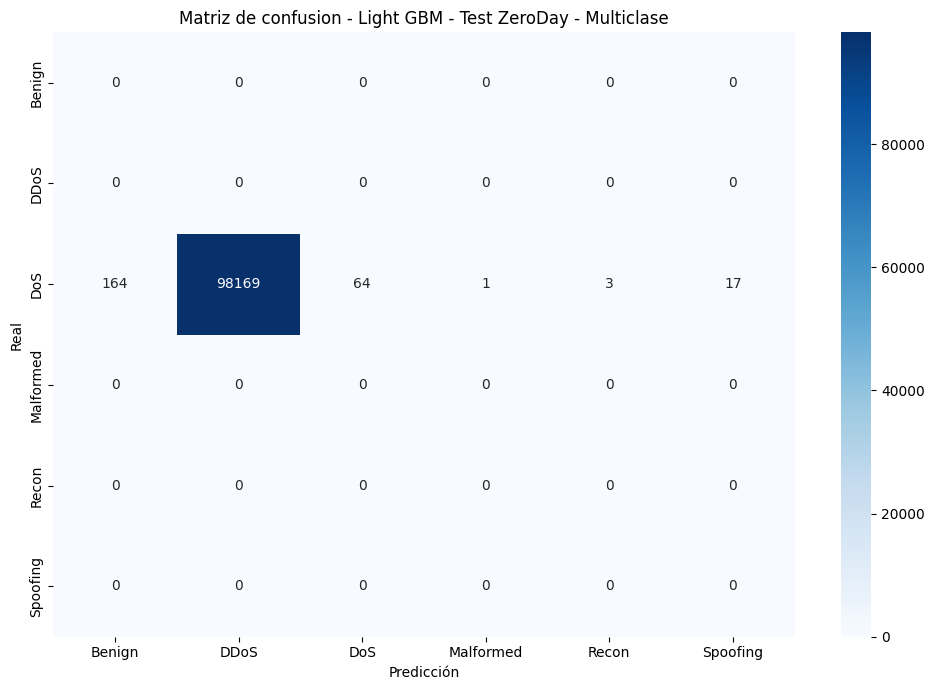

Tasa de detección de ataques ZeroDay (Multiclase): 0.9983


In [5]:
lgbm_pipe_multiclase = construccion_lgbm_pipeline_multiclase(objective="multiclass",n_estimators = 400, num_leaves = 64, learning_rate = 0.05, subsample = 0.9, colsample_bytree = 0.9, random_state = 19, n_jobs=-1, verbose=-1)
lgbm_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase)
clases_multiclase = lgbm_pipe_multiclase.named_steps["lgbm"].classes_

print("\n==== LIGHT GBM - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_lgbm_multiclase(
    lgbm_pipe_multiclase, 
    x_val_multiclase, 
    y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

if not np.isnan(auc_val_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_val_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

# TEST KNOWN
print("\n==== LIGHT GBM - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_lgbm_multiclase(
    lgbm_pipe_multiclase, 
    x_test_known_multiclase, 
    y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

if not np.isnan(auc_test_known_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test Known - Multiclase: {auc_test_known_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Light GBM - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_lgbm}/matriz_confusion_lgbm_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== LIGHT GBM - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_lgbm_multiclase(
    lgbm_pipe_multiclase, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

if not np.isnan(auc_test_zeroday_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test ZeroDay - Multiclase: {auc_test_zeroday_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Light GBM - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_lgbm}/matriz_confusion_lgbm_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# XGBoost

In [2]:
from Scripts_modelos_supervisados.XGBboost import construccion_xgb_pipeline, evaluar_xgb_binario, evaluar_xgb_multiclase
from sklearn.preprocessing import LabelEncoder
carpeta_salida_xgb = "Resultados/XGBboost"
os.makedirs(carpeta_salida_xgb, exist_ok= True)

#### Clasificacion Binaria

c:\Users\alext\Desktop\TFG Alejandro\tfg-entornovirtual\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:44:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==== XGBOOST - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.72      1.00      0.83      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.86      1.00      0.92    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.7160,1.0000,0.8345,1929.0000
1,1.0000,0.9988,0.9994,652147.0000
accuracy,0.9988,0.9988,0.9988,0.9988
macro avg,0.8580,0.9994,0.9170,654076.0000
weighted avg,0.9992,0.9988,0.9989,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1929      0]
 [   765 651382]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 1.000

==== XGBOOST - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.77      0.18      0.29     37604
           1       0.98      1.00      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.88      0.59      0.64   2022118
weighted avg       0.98      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.7670,0.1751,0.2851,3.760400e+04
1,0.9846,0.9990,0.9917,1.984514e+06
accuracy,0.9837,0.9837,0.9837,9.837000e-01
macro avg,0.8758,0.5870,0.6384,2.022118e+06
weighted avg,0.9805,0.9837,0.9786,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[   6584   31020]
 [   2000 1982514]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.968


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

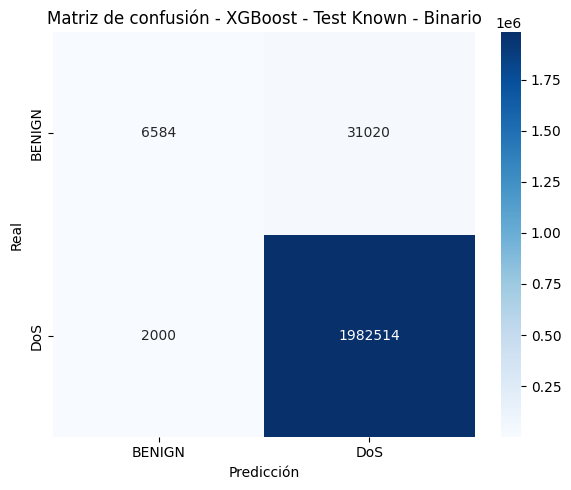


==== XGBOOST - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9973,0.9987,98418.0000
accuracy,0.9973,0.9973,0.9973,0.9973
macro avg,0.5000,0.4987,0.4993,98418.0000
weighted avg,1.0000,0.9973,0.9987,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  263 98155]]

No se pudo calcular el area bajo la curva ROC


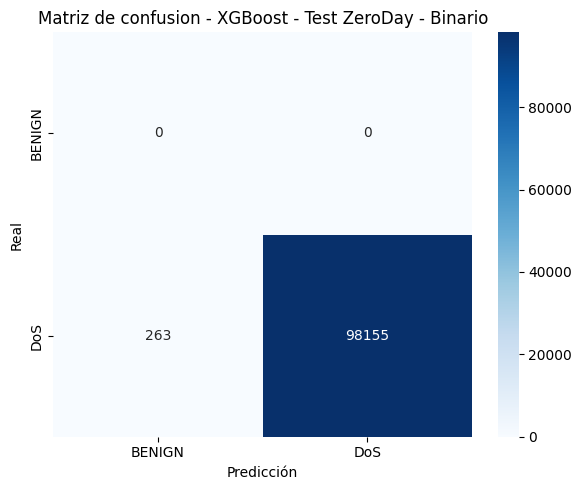

Tasa de detección de ataques ZeroDay - Binario: 0.9973


In [7]:
xgb_pipe_binario = construccion_xgb_pipeline(n_estimators = 400, max_depth = 8, learning_rate = 0.05, subsample = 0.9, colsample_bytree = 0.9, random_state = 19)
xgb_pipe_binario.fit(x_train_binario_undersampling, y_train_binario_undersampling)

print("\n==== XGBOOST - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_xgb_binario(
    xgb_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_xgb,
    "roc_xgb_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== XGBOOST - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_xgb_binario(
    xgb_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_xgb,
    "roc_xgb_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - XGBoost - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_xgb, "matriz_confusion_xgb_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== XGBOOST - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_xgb_binario(
    xgb_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_xgb, 
    "roc_xgb_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - XGBoost - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_xgb, "matriz_confusion_xgb_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")



#### Clasificacion Multiclase

Comprobacion antes de label encoder:
Attack_family
DDoS         4470228
DoS          1301724
Recon          78445
Benign         17362
Spoofing       14376
Malformed       4542
Name: count, dtype: int64
DEBUG
<class 'numpy.ndarray'>
['Benign' 'DDoS' 'DoS' 'Malformed' 'Recon' 'Spoofing']
['Benign' 'DDoS' 'DoS' 'Malformed' 'Recon' 'Spoofing']
------------------------
Clases multiclase para XGBoost (Label Encoder):
['Benign' 'DDoS' 'DoS' 'Malformed' 'Recon' 'Spoofing']


c:\Users\alext\Desktop\TFG Alejandro\tfg-entornovirtual\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:36:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==== XGBOOST - VALIDACION - MULTICLASE ====
Informe de clasificacion - Validacion - Multiclase:

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1929
           1       0.95      0.91      0.93    496693
           2       0.73      0.83      0.78    144636
           3       0.85      0.59      0.70       505
           4       0.97      0.94      0.96      8716
           5       0.68      0.85      0.76      1597

    accuracy                           0.89    654076
   macro avg       0.85      0.84      0.84    654076
weighted avg       0.90      0.89      0.90    654076



,precision,recall,f1-score,support
0,0.9296,0.9445,0.9370,1929.000
1,0.9480,0.9114,0.9293,496693.000
2,0.7311,0.8277,0.7764,144636.000
3,0.8543,0.5921,0.6994,505.000
4,0.9669,0.9440,0.9553,8716.000
5,0.6813,0.8472,0.7552,1597.000
accuracy,0.8930,0.8930,0.8930,0.893
macro avg,0.8518,0.8445,0.8421,654076.000
weighted avg,0.8995,0.8930,0.8953,654076.000



Matriz de confusion - Validacion - Multiclase:

[[  1822      4    103      0      0      0]
 [    62 452675  43937      5      9      5]
 [    76  24839 119711      1      5      4]
 [     0      0      0    299     68    138]
 [     0      1      0      1   8228    486]
 [     0      0      0     44    200   1353]]

==== XGBOOST - TEST KNOWN - MULTICLASE ====
Informe de clasificacion - Test Known - Multiclase:

              precision    recall  f1-score   support

           0       0.41      0.01      0.01     37604
           1       0.94      0.64      0.76   1525492
           2       0.74      0.59      0.66    430423
           3       0.00      0.23      0.00      1737
           4       0.08      0.95      0.15     20997
           5       0.02      0.60      0.04      5865

    accuracy                           0.62   2022118
   macro avg       0.36      0.50      0.27   2022118
weighted avg       0.87      0.62      0.72   2022118



,precision,recall,f1-score,support
0,0.4079,0.0063,0.0124,3.760400e+04
1,0.9360,0.6406,0.7606,1.525492e+06
2,0.7376,0.5923,0.6570,4.304230e+05
3,0.0017,0.2291,0.0034,1.737000e+03
4,0.0810,0.9501,0.1492,2.099700e+04
5,0.0223,0.5956,0.0431,5.865000e+03
accuracy,0.6213,0.6213,0.6213,6.213000e-01
macro avg,0.3644,0.5023,0.2710,2.022118e+06
weighted avg,0.8716,0.6213,0.7156,2.022118e+06



Matriz de confusion - Test Known - Multiclase:

[[   237      5      0     26   9302  28034]
 [   277 977259  90718 218529 175850  62859]
 [    17  66767 254947  10035  38642  60015]
 [     0     21      0    398    345    973]
 [     0      1      0     18  19950   1028]
 [    50      8      0     52   2262   3493]]


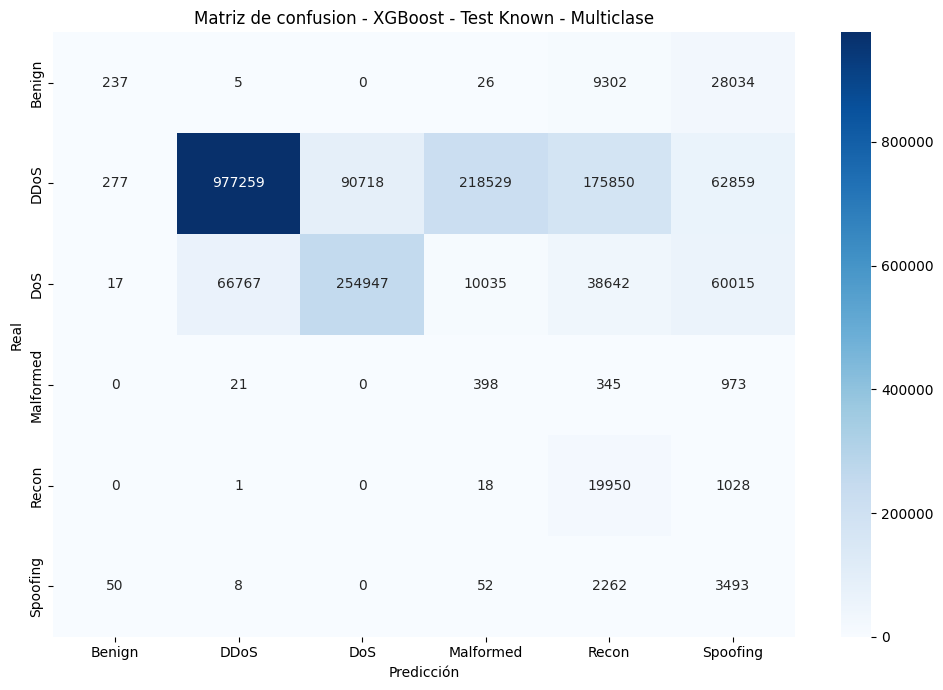


==== XGBOOST - TEST ZERODAY - MULTICLASE ====
Informe de clasificacion - Test ZeroDay - Multiclase:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       1.00      0.00      0.00     98418

    accuracy                           0.00     98418
   macro avg       0.33      0.00      0.00     98418
weighted avg       1.00      0.00      0.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000,0.0000
2,1.0000,0.0007,0.0014,98418.0000
accuracy,0.0007,0.0007,0.0007,0.0007
macro avg,0.3333,0.0002,0.0005,98418.0000
weighted avg,1.0000,0.0007,0.0014,98418.0000



Matriz de confusion - Test ZeroDay - Multiclase:

[[    0     0     0]
 [    0     0     0]
 [  199 98148    71]]


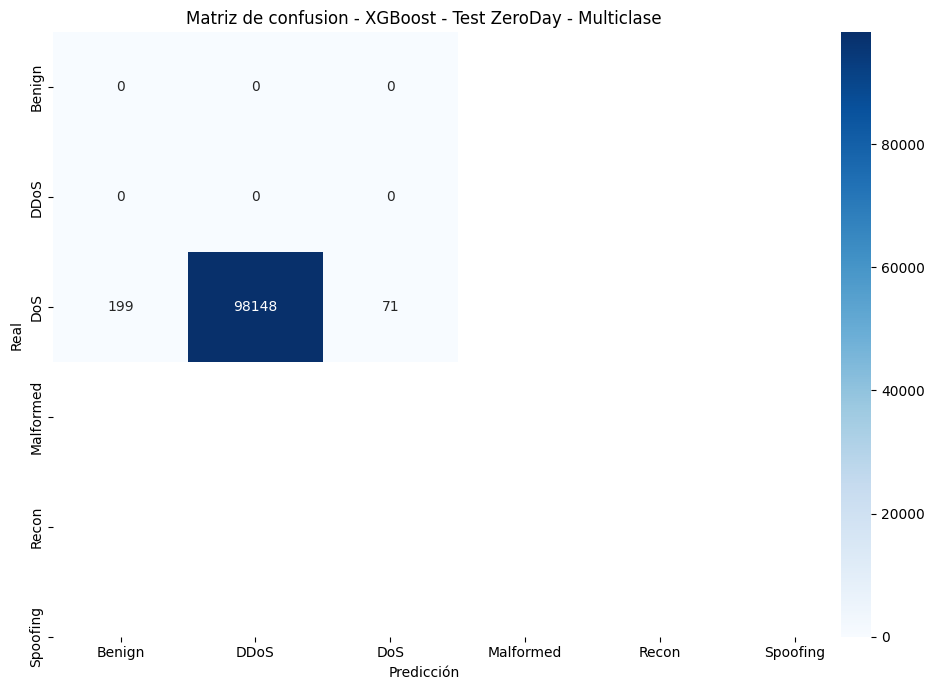

Tasa de detección de ataques ZeroDay (Multiclase): 0.9980


In [6]:
label_encoder_xgb = LabelEncoder()

print("Comprobacion antes de label encoder:")
print(y_train_multiclase.value_counts())
y_train_multiclase_encoder = label_encoder_xgb.fit_transform(y_train_multiclase)

y_val_multiclase_encoder = label_encoder_xgb.transform(y_val_multiclase)
y_test_known_multiclase_encoder = label_encoder_xgb.transform(y_test_known_multiclase)
y_test_zeroday_multiclase_encoder = label_encoder_xgb.transform(y_test_zeroday_multiclase)
#clases_multiclase = xgb_pipe_multiclase.named_steps["xgb"].classes_
clases_multiclase = label_encoder_xgb.classes_

print("DEBUG")
print(type(clases_multiclase))
print(clases_multiclase)
print(label_encoder_xgb.classes_)
print("------------------------")

print("Clases multiclase para XGBoost (Label Encoder):")
print(clases_multiclase)

xgb_pipe_multiclase = construccion_xgb_pipeline(n_estimators = 100, max_depth = 4, learning_rate = 0.05, subsample = 0.9, colsample_bytree = 0.9, random_state = 19)
xgb_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase_encoder)
print("\n==== XGBOOST - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase = evaluar_xgb_multiclase(
    xgb_pipe_multiclase, 
    x_val_multiclase, 
    y_val_multiclase_encoder)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

# TEST KNOWN
print("\n==== XGBOOST - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase = evaluar_xgb_multiclase(
    xgb_pipe_multiclase, 
    x_test_known_multiclase, 
    y_test_known_multiclase_encoder)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - XGBoost - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_xgb}/matriz_confusion_xgb_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== XGBOOST - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase = evaluar_xgb_multiclase(
    xgb_pipe_multiclase, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase_encoder)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - XGBoost - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_xgb}/matriz_confusion_xgb_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# TABNET

In [2]:
from Scripts_modelos_supervisados.TabNet import construccion_tabnet_pipeline, evaluar_tabnet_binario, evaluar_tabnet_multiclase, entrenar_tabnet_pipeline

carpeta_salida_tabnet = "Resultados/TabNet"
os.makedirs(carpeta_salida_tabnet, exist_ok= True)

#### Clasificacion binaria


Early stopping occurred at epoch 17 with best_epoch = 7 and best_val_0_auc = 0.99986


c:\Users\alext\Desktop\TFG Alejandro\tfg-entornovirtual\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



==== TABNET - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.35      1.00      0.52      1929
           1       1.00      0.99      1.00    652147

    accuracy                           0.99    654076
   macro avg       0.68      1.00      0.76    654076
weighted avg       1.00      0.99      1.00    654076



,precision,recall,f1-score,support
0,0.3527,1.0000,0.5214,1929.0000
1,1.0000,0.9946,0.9973,652147.0000
accuracy,0.9946,0.9946,0.9946,0.9946
macro avg,0.6763,0.9973,0.7593,654076.0000
weighted avg,0.9981,0.9946,0.9959,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1929      0]
 [  3541 648606]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 1.000

==== TABNET - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.17      0.80      0.28     37604
           1       1.00      0.93      0.96   1984514

    accuracy                           0.92   2022118
   macro avg       0.58      0.86      0.62   2022118
weighted avg       0.98      0.92      0.95   2022118



,precision,recall,f1-score,support
0,0.1680,0.7973,0.2775,3.760400e+04
1,0.9959,0.9252,0.9592,1.984514e+06
accuracy,0.9228,0.9228,0.9228,9.228000e-01
macro avg,0.5819,0.8612,0.6183,2.022118e+06
weighted avg,0.9805,0.9228,0.9465,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[  29981    7623]
 [ 148517 1835997]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.921


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

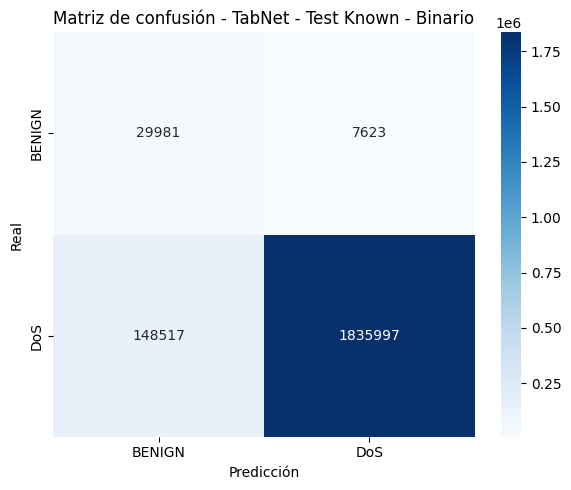


==== TABNET - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9964,0.9982,98418.0000
accuracy,0.9964,0.9964,0.9964,0.9964
macro avg,0.5000,0.4982,0.4991,98418.0000
weighted avg,1.0000,0.9964,0.9982,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  350 98068]]

No se pudo calcular el area bajo la curva ROC


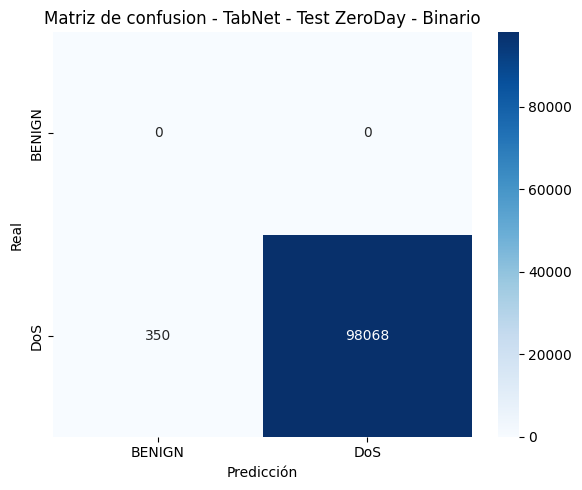

Tasa de detección de ataques ZeroDay - Binario: 0.9964


In [3]:
tabnet_pipe_construccion_binario = construccion_tabnet_pipeline(n_d = 8, n_a = 8, n_steps = 3, gamma = 1.3, lambda_sparse = 1e-3, seed = 19, lr = 2e-2, step_size = 50, step_gamma = 0.9)
tabnet_pipe_binario = entrenar_tabnet_pipeline(tabnet_pipe_construccion_binario, x_train_binario_undersampling, y_train_binario_undersampling, x_val_binario, y_val_binario, max_epochs=60, patience=10, batch_size=2048, virtual_batch_size=256)


# VALIDACION
print("\n==== TABNET - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_tabnet_binario(
    tabnet_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_tabnet,
    "roc_tabnet_val_binario.png",
    0.8
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== TABNET - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_tabnet_binario(
    tabnet_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_tabnet,
    "roc_tabnet_test_known_binario.png",
    0.8
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - TabNet - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_tabnet, "matriz_confusion_tabnet_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== TABNET - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_tabnet_binario(
    tabnet_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_tabnet, 
    "roc_tabnet_test_zeroday_binario.png",
    0.8
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - TabNet - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_tabnet, "matriz_confusion_tabnet_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")


#### Clasificacion Multiclase

(294333, 38)
Attack_family
DDoS         223511
DoS           65086
Recon          3922
Benign          868
Spoofing        719
Malformed       227
Name: count, dtype: int64
(32704, 38)
Attack_family
DDoS         24835
DoS           7232
Recon          436
Benign          96
Spoofing        80
Malformed       25
Name: count, dtype: int64

Early stopping occurred at epoch 48 with best_epoch = 38 and best_val_0_accuracy = 0.90047


c:\Users\alext\Desktop\TFG Alejandro\tfg-entornovirtual\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



==== TABNET - VALIDACION - MULTICLASE ====
Informe de clasificacion - Validacion - Multiclase:

              precision    recall  f1-score   support

      Benign       0.84      0.88      0.86      1929
        DDoS       0.94      0.92      0.93    496693
         DoS       0.76      0.81      0.78    144636
   Malformed       0.88      0.31      0.46       505
       Recon       0.91      0.97      0.94      8716
    Spoofing       0.63      0.56      0.59      1597

    accuracy                           0.90    654076
   macro avg       0.83      0.74      0.76    654076
weighted avg       0.90      0.90      0.90    654076



,precision,recall,f1-score,support
Benign,0.8372,0.8771,0.8567,1929.0000
DDoS,0.9443,0.9233,0.9337,496693.0000
DoS,0.7552,0.8120,0.7826,144636.0000
Malformed,0.8827,0.3129,0.4620,505.0000
Recon,0.9134,0.9701,0.9409,8716.0000
Spoofing,0.6285,0.5560,0.5900,1597.0000
accuracy,0.8978,0.8978,0.8978,0.8978
macro avg,0.8269,0.7419,0.7610,654076.0000
weighted avg,0.9009,0.8978,0.8989,654076.0000



Matriz de confusion - Validacion - Multiclase:

[[  1692     50    187      0      0      0]
 [   165 458617  37869      1     33      8]
 [   164  26998 117449      0     21      4]
 [     0      5      0    158     65    277]
 [     0     20      1      4   8455    236]
 [     0      3      7     16    683    888]]

==== TABNET - TEST KNOWN - MULTICLASE ====
Informe de clasificacion - Test Known - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00     37604
        DDoS       0.92      0.68      0.79   1525492
         DoS       0.73      0.54      0.62    430423
   Malformed       0.00      0.05      0.00      1737
       Recon       0.06      0.99      0.12     20997
    Spoofing       0.01      0.27      0.02      5865

    accuracy                           0.64   2022118
   macro avg       0.29      0.42      0.26   2022118
weighted avg       0.85      0.64      0.73   2022118



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,3.760400e+04
DDoS,0.9218,0.6843,0.7855,1.525492e+06
DoS,0.7281,0.5383,0.6190,4.304230e+05
Malformed,0.0011,0.0524,0.0021,1.737000e+03
Recon,0.0645,0.9869,0.1212,2.099700e+04
Spoofing,0.0094,0.2656,0.0181,5.865000e+03
accuracy,0.6419,0.6419,0.6419,6.419000e-01
macro avg,0.2875,0.4213,0.2577,2.022118e+06
weighted avg,0.8511,0.6419,0.7257,2.022118e+06



Matriz de confusion - Test Known - Multiclase:

[[      0     787       1       7   30805    6004]
 [    683 1043948   86520   76493  198091  119757]
 [     33   87698  231703    7139   66711   37139]
 [      0       1       0      91     474    1171]
 [      0      23       0       2   20721     251]
 [      0      24       2      10    4271    1558]]


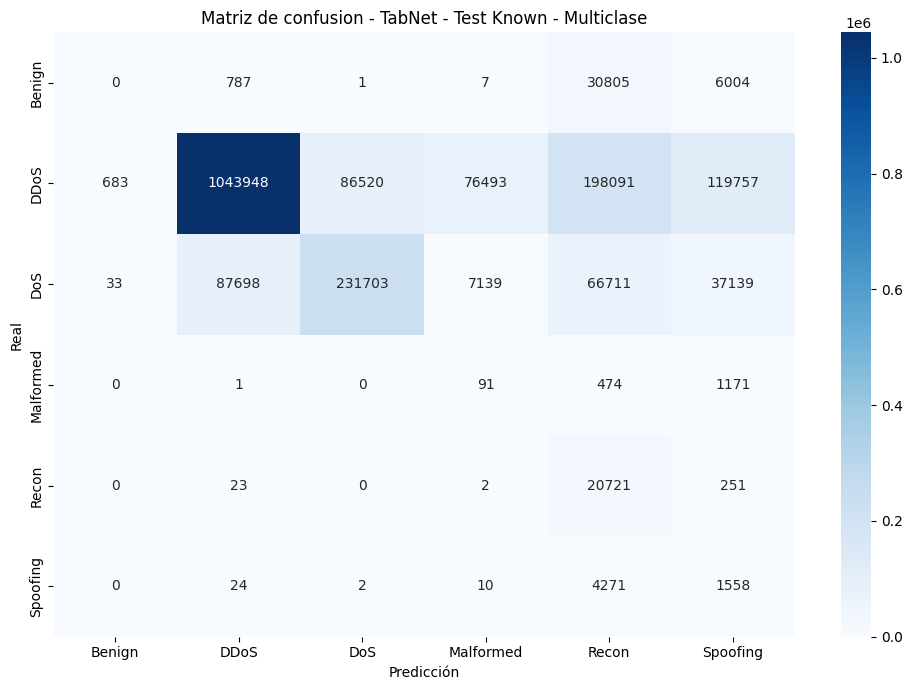


==== TABNET - TEST ZERODAY - MULTICLASE ====
Informe de clasificacion - Test ZeroDay - Multiclase:

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00         0
        DDoS       0.00      0.00      0.00         0
         DoS       1.00      0.00      0.00     98418
       Recon       0.00      0.00      0.00         0
    Spoofing       0.00      0.00      0.00         0

    accuracy                           0.00     98418
   macro avg       0.20      0.00      0.00     98418
weighted avg       1.00      0.00      0.00     98418



,precision,recall,f1-score,support
Benign,0.0000,0.0000,0.0000,0.0000
DDoS,0.0000,0.0000,0.0000,0.0000
DoS,1.0000,0.0014,0.0028,98418.0000
Recon,0.0000,0.0000,0.0000,0.0000
Spoofing,0.0000,0.0000,0.0000,0.0000
accuracy,0.0014,0.0014,0.0014,0.0014
macro avg,0.2000,0.0003,0.0006,98418.0000
weighted avg,1.0000,0.0014,0.0028,98418.0000



Matriz de confusion - Test ZeroDay - Multiclase:

[[    0     0     0     0     0]
 [    0     0     0     0     0]
 [  187 98089   139     2     1]
 [    0     0     0     0     0]
 [    0     0     0     0     0]]


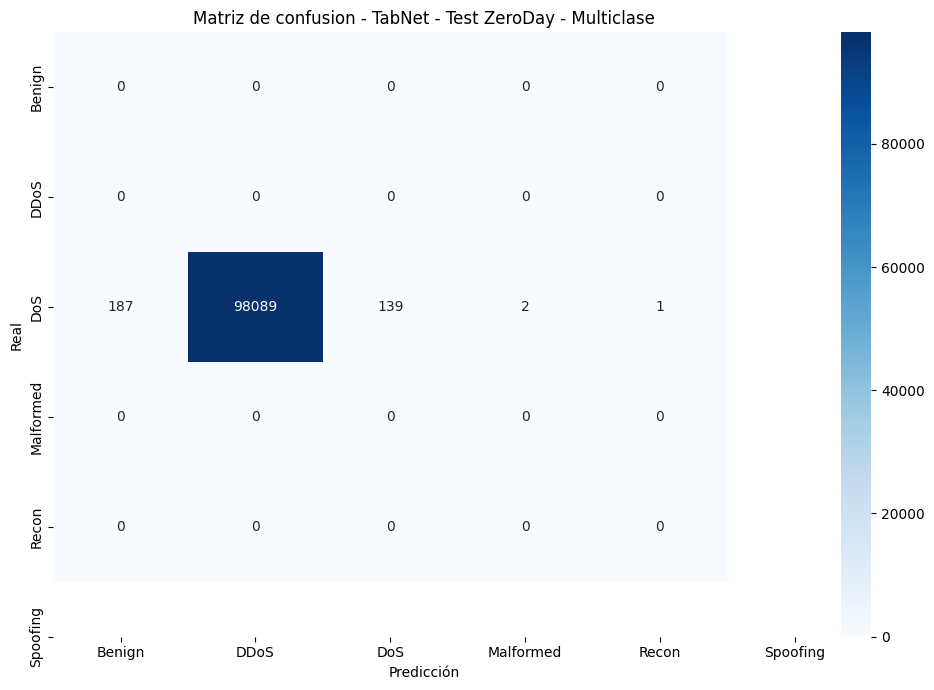

Tasa de detección de ataques ZeroDay (Multiclase): 0.9981


In [3]:
tabnet_pipe_construccion_multiclase = construccion_tabnet_pipeline(n_d = 8, n_a = 8, n_steps = 3, gamma = 1.3, lambda_sparse = 1e-3, seed = 19, lr = 2e-2, step_size = 50, step_gamma = 0.9)
#REDUCIMOS NUMERO DE MUESTRAS DE ENTRENAMIENTO -> Tanto de entrenamiento como de evaluacion
indices_tabnet_multiclase = (y_train_multiclase.groupby(y_train_multiclase).sample(frac=0.05, random_state=19).index)
x_train_multiclase_tabnet = x_train_multiclase.loc[indices_tabnet_multiclase]
y_train_multiclase_tabnet = y_train_multiclase.loc[indices_tabnet_multiclase]
print(x_train_multiclase_tabnet.shape)
print(y_train_multiclase_tabnet.value_counts())

indices_val_tabnet_multiclase = (y_val_multiclase.groupby(y_val_multiclase).sample(frac=0.05, random_state=19).index)
x_val_multiclase_tabnet = x_val_multiclase.loc[indices_val_tabnet_multiclase]
y_val_multiclase_tabnet = y_val_multiclase.loc[indices_val_tabnet_multiclase]
print(x_val_multiclase_tabnet.shape)
print(y_val_multiclase_tabnet.value_counts())

tabnet_pipe_multiclase = entrenar_tabnet_pipeline(tabnet_pipe_construccion_multiclase, x_train_multiclase_tabnet, y_train_multiclase_tabnet, x_val_multiclase_tabnet, y_val_multiclase_tabnet, max_epochs=60, patience=10, batch_size=2048, virtual_batch_size=256)
clases_multiclase = tabnet_pipe_multiclase.named_steps["tabnet"].classes_

print("\n==== TABNET - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase = evaluar_tabnet_multiclase(
    tabnet_pipe_multiclase, 
    x_val_multiclase, 
    y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

# TEST KNOWN
print("\n==== TABNET - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase = evaluar_tabnet_multiclase(
    tabnet_pipe_multiclase, 
    x_test_known_multiclase, 
    y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - TabNet - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_tabnet}/matriz_confusion_tabnet_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== TABNET - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase = evaluar_tabnet_multiclase(
    tabnet_pipe_multiclase, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - TabNet - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_tabnet}/matriz_confusion_tabnet_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# **Modelos de aprendizaje no supervisado**
- K-means
- Isolation Forest

# K-Means


In [3]:
from Scripts_modelos_no_supervisados.kmeans import construccion_kmeans_pipeline, seleccionar_mejor_k_por_silhouette, crear_mapeo_cluster_clase, evaluar_kmeans_binario, evaluar_kmeans_multiclase

carpeta_salida_kmeans = "Resultados/Kmeans"
os.makedirs(carpeta_salida_kmeans, exist_ok= True)

#### Clasificacion Binaria

In [4]:
mejor_k_binario, silhouette_val_binario = seleccionar_mejor_k_por_silhouette(x_train_binario, x_val_binario, k_candidates=(2,3,4,5,6,8,10), random_state=19, n_init=10, sample_size=5000)

c:\Users\alext\Desktop\TFG Alejandro\tfg-entornovirtual\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\alext\Desktop\TFG Alejandro\tfg-entornovirtual\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subproce

K=2 -> Silhouette=0.6108
K=3 -> Silhouette=0.0186
K=4 -> Silhouette=-0.3845
K=5 -> Silhouette=-0.4289
K=6 -> Silhouette=-0.4289
K=8 -> Silhouette=-0.4504
K=10 -> Silhouette=-0.4491



Distribución validación balanceada para mapping K-Means:
Binary_label
1    1929
0    1929
Name: count, dtype: int64

Tamaño de X: (3858, 38)
Tamaño de Y: (3858,)
Mapeo Binario
{0: np.int64(1), 1: np.int64(0)}

==== K-MEANS - VALIDACION (BINARIO) ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.11      0.83      0.20      1929
           1       1.00      0.98      0.99    652147

    accuracy                           0.98    654076
   macro avg       0.56      0.91      0.59    654076
weighted avg       1.00      0.98      0.99    654076



,precision,recall,f1-score,support
0,0.1136,0.8320,0.1999,1929.0000
1,0.9995,0.9808,0.9901,652147.0000
accuracy,0.9804,0.9804,0.9804,0.9804
macro avg,0.5565,0.9064,0.5950,654076.0000
weighted avg,0.9969,0.9804,0.9877,654076.0000


Matriz de confusion - Validacion - Binario:

[[  1605    324]
 [ 12525 639622]]
Adjusted Rand Index (ARI) - Validacion - Binario: 0.1918
Silhouette Score: 0.6104

Mapeo cluster -> clase: 
{0: np.int64(1), 1: np.int64(0)}

==== K-MEANS - TEST KNOWN (BINARIO) ====
Informe de clasificacion - Test Known - Binario:

              precision    recall  f1-score   support

           0       0.09      0.31      0.14     37604
           1       0.99      0.94      0.96   1984514

    accuracy                           0.93   2022118
   macro avg       0.54      0.63      0.55   2022118
weighted avg       0.97      0.93      0.95   2022118



,precision,recall,f1-score,support
0,0.0906,0.3108,0.1402,3.760400e+04
1,0.9863,0.9408,0.9630,1.984514e+06
accuracy,0.9291,0.9291,0.9291,9.291000e-01
macro avg,0.5384,0.6258,0.5516,2.022118e+06
weighted avg,0.9697,0.9291,0.9477,2.022118e+06


Matriz de confusion - Test Known - Binario:

[[  11688   25916]
 [ 117387 1867127]]
Adjusted Rand Index (ARI) - Test Known - Binario: 0.1059
Silhouette Score: 0.4642

Mapeo cluster -> clase: 
{0: np.int64(1), 1: np.int64(0)}


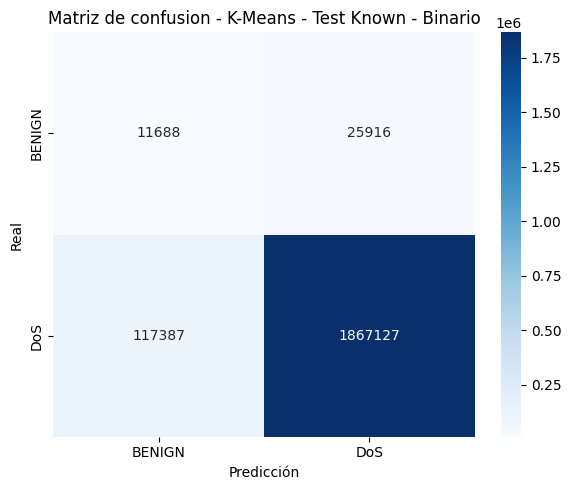


==== K-MEANS - ZERO DAY (BINARIO) ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      0.99     98418

    accuracy                           0.99     98418
   macro avg       0.50      0.49      0.50     98418
weighted avg       1.00      0.99      0.99     98418



,precision,recall,f1-score,support
0,0.00,0.000,0.0000,0.00
1,1.00,0.990,0.9950,98418.00
accuracy,0.99,0.990,0.9900,0.99
macro avg,0.50,0.495,0.4975,98418.00
weighted avg,1.00,0.990,0.9950,98418.00


Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  986 97432]]
Adjusted Rand Index (ARI) - Test ZeroDay - Binario: 0.0000
Silhouette Score: 0.9263

Mapeo cluster -> clase: 
{0: np.int64(1), 1: np.int64(0)}


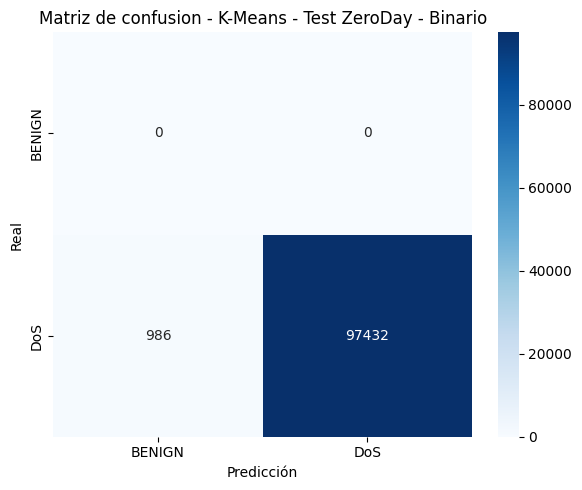

Tasa de detección ataques ZeroDay (Binario): 0.9900


In [ ]:

#UNDERSAMPLING 1:1 PARA MAPPING DE K-MEANS
df_val_binario = x_val_binario.copy()
df_val_binario["Binary_label"] = y_val_binario.values

df_val_benigno = df_val_binario[df_val_binario["Binary_label"] == 0].copy()
df_val_ataque = df_val_binario[df_val_binario["Binary_label"] == 1].copy()

df_val_ataque_muestras = df_val_ataque.sample(
    n=len(df_val_benigno),
    random_state=19
)

df_val_mapping = pd.concat([df_val_benigno, df_val_ataque_muestras], axis=0)

df_val_mapping = df_val_mapping.sample(frac=1, random_state=19).reset_index(drop=True)

x_val_mapping_binario = df_val_mapping.drop(columns=["Binary_label"])
y_val_mapping_binario = df_val_mapping["Binary_label"]

print("\nDistribución validación balanceada para mapping K-Means:")
print(y_val_mapping_binario.value_counts())
print("\nTamaño de X:", x_val_mapping_binario.shape)
print("Tamaño de Y:", y_val_mapping_binario.shape)

kmeans_pipe_binario = construccion_kmeans_pipeline(n_clusters=2, random_state=19, n_init=10)
kmeans_pipe_binario.fit(x_train_binario)
clusters_val_mapping_binario = kmeans_pipe_binario.predict(x_val_mapping_binario)
mapping_binario = crear_mapeo_cluster_clase(clusters_val_mapping_binario, y_val_mapping_binario)
print("Mapeo Binario")
print(mapping_binario)

print("\n==== K-MEANS - VALIDACION (BINARIO) ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, ari_val_binario, silhouette_val_binario, mapping_val_binario = evaluar_kmeans_binario(kmeans_pipe_binario, mapping_binario, x_val_binario, y_val_binario, sample_size=10000)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
print(f"Adjusted Rand Index (ARI) - Validacion - Binario: {ari_val_binario:.4f}")
if not np.isnan(silhouette_val_binario):
    print(f"Silhouette Score: {silhouette_val_binario:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_val_binario)

print("\n==== K-MEANS - TEST KNOWN (BINARIO) ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario,matriz_test_known_binario, ari_test_known_binario, silhouette_test_known_binario, mapping_test_known_binario = evaluar_kmeans_binario(kmeans_pipe_binario, mapping_binario, x_test_known_binario, y_test_known_binario, sample_size=10000)
print("Informe de clasificacion - Test Known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("Matriz de confusion - Test Known - Binario:\n")
print(matriz_test_known_binario)
print(f"Adjusted Rand Index (ARI) - Test Known - Binario: {ari_test_known_binario:.4f}")
if not np.isnan(silhouette_test_known_binario):
    print(f"Silhouette Score: {silhouette_test_known_binario:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_test_known_binario)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - K-Means - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_kmeans, "matriz_confusion_kmeans_binario_test_known.png"))
plt.show()


print("\n==== K-MEANS - ZERO DAY (BINARIO) ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, ari_test_zeroday_binario, silhouette_test_zeroday_binario, mapping_test_zeroday_binario = evaluar_kmeans_binario(kmeans_pipe_binario, mapping_binario, x_test_zeroday_binario, y_test_zeroday_binario, sample_size=10000)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
print(f"Adjusted Rand Index (ARI) - Test ZeroDay - Binario: {ari_test_zeroday_binario:.4f}")
if not np.isnan(silhouette_test_zeroday_binario):
    print(f"Silhouette Score: {silhouette_test_zeroday_binario:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_test_known_binario)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - K-Means - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_kmeans, "matriz_confusion_kmeans_binario_test_zeroday.png"))
plt.show()

tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección ataques ZeroDay (Binario): {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador binario.")

#### Clasificacion Multiclase

In [5]:
mejor_k_multiclase, silhouette_val_multiclase = seleccionar_mejor_k_por_silhouette(x_train_multiclase, x_val_multiclase, k_candidates=(2,3,4,5,6,8,10), random_state=19, n_init=10)

K=2 -> Silhouette=0.6302
K=3 -> Silhouette=-0.0006
K=4 -> Silhouette=-0.0149
K=5 -> Silhouette=-0.1988
K=6 -> Silhouette=-0.3676
K=8 -> Silhouette=-0.3580
K=10 -> Silhouette=-0.3783


In [ ]:
x_train_kmeans_multiclase = x_train_multiclase.sample(n=100000, random_state=19)
kmeans_pipe_multiclase = construccion_kmeans_pipeline(n_clusters=6, random_state=19, n_init=5) #n_cluesters=6
kmeans_pipe_multiclase.fit(x_train_kmeans_multiclase)
clusters_val_multiclase = kmeans_pipe_multiclase.predict(x_val_multiclase)
mapping_multiclase = crear_mapeo_cluster_clase(clusters_val_multiclase, y_val_multiclase)
clases_multiclase = sorted(y_train_multiclase.unique())

print("\n==== K-MEANS - VALIDACION (MULTICLASE) ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, ari_val_multiclase, silhouette_val_multiclase, mapping_val_multiclase = evaluar_kmeans_multiclase(kmeans_pipe_multiclase, mapping_multiclase, x_val_multiclase, y_val_multiclase, sample_size=5000)
print("Informe de clasificacion K-Means validacion multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("Matriz de confusion:\n")
print(matriz_val_multiclase)
print(f"Adjusted Rand Index (ARI): {ari_val_multiclase:.4f}")
if not np.isnan(silhouette_val_multiclase):
    print(f"Silhouette Score: {silhouette_val_multiclase:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_val_multiclase)

print("\n==== K-MEANS - TEST KNOWN (MULTICLASE) ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase ,matriz_test_known_multiclase, ari_test_known_multiclase, silhouette_test_known_multiclase, mapping_test_known_multiclase = evaluar_kmeans_multiclase(kmeans_pipe_multiclase, mapping_multiclase, x_test_known_multiclase, y_test_known_multiclase, sample_size=5000)
print("Informe de clasificación K-Means Test Known multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("Matriz de confusion:\n")
print(matriz_test_known_multiclase)
print(f"Adjusted Rand Index (ARI): {ari_test_known_multiclase:.4f}")
if not np.isnan(silhouette_test_known_multiclase):
    print(f"Silhouette Score: {silhouette_test_known_multiclase:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_test_known_multiclase)

#Matriz de confusion test known multiclase 
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - K-Means - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_kmeans}/matriz_confusion_kmeans_multiclase_test_known.png")
plt.show()

print("\n==== K-MEANS - ZERO DAY (MULTICLASE) ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase ,matriz_test_zeroday_multiclase, ari_test_zeroday_multiclase, silhouette_test_zeroday_multiclase, mapping_test_zeroday_multiclase = evaluar_kmeans_multiclase(kmeans_pipe_multiclase, mapping_multiclase, x_test_zeroday_multiclase, y_test_zeroday_multiclase, sample_size=5000)
print("Informe de clasificacion K-Means validacion multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("Matriz de confusion:\n")
print(matriz_test_zeroday_multiclase)
print(f"Adjusted Rand Index (ARI): {ari_test_zeroday_multiclase:.4f}")
if not np.isnan(silhouette_test_zeroday_multiclase):
    print(f"Silhouette Score: {silhouette_test_zeroday_multiclase:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_test_zeroday_multiclase)

indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

# Isolation Forest

In [2]:
from Scripts_modelos_no_supervisados.isolation_forest import construccion_isolation_pipeline, seleccionar_umbral_por_f1, evaluar_isolation_binario

carpeta_salida_isolation = "Resultados/IsolationForest"
os.makedirs(carpeta_salida_isolation, exist_ok=True)

#### Clasificacion Binaria


Tamaño de X: (17362, 38)
==== ISOLATION FOREST - SELECTOR DE UMBRAL ====
Mejor percentil: 80
Mejor umbral: -0.623472
F1 en validacion: 0.8903

==== ISOLATION FOREST - VALIDACION (BINARIO) ====
              precision    recall  f1-score   support

           0       0.01      0.99      0.03      1929
           1       1.00      0.80      0.89    652147

    accuracy                           0.80    654076
   macro avg       0.51      0.90      0.46    654076
weighted avg       1.00      0.80      0.89    654076


Matriz de confusion:
[[  1907     22]
 [128913 523234]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.995

==== ISOLATION FOREST - TEST KNOWN (BINARIO) ====
              precision    recall  f1-score   support

           0       0.06      0.87      0.12     37604
           1       1.00      0.76      0.86   1984514

    accuracy                           0.76   2022118
   macro avg       0.53      0.81      0.49   2022118
weighted avg       0.98      0.76  

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

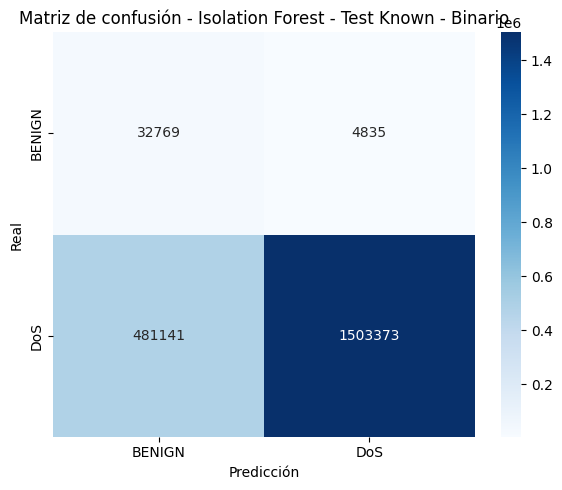


==== ISOLATION FOREST - TEST ZERODAY (BINARIO) ====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      1.00     98418

    accuracy                           0.99     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      0.99      1.00     98418


Matriz de confusion:
[[    0     0]
 [  525 97893]]

No se pudo calcular el area bajo la curva ROC


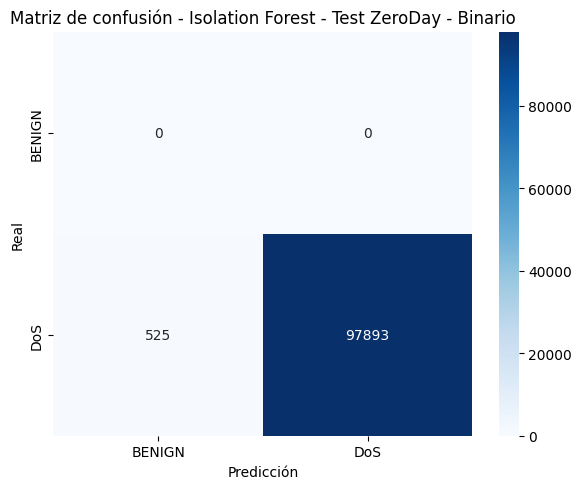

Tasa de detección ataques ZeroDay (Binario): 0.9947


In [5]:
x_train_benigno = x_train_binario[y_train_binario == 0]
print("\nTamaño de X:", x_train_benigno.shape)

isolation_pipeline_binario = construccion_isolation_pipeline(n_estimators=200, max_samples="auto", contamination="auto", random_state=19, n_jobs=-1)

isolation_pipeline_binario.fit(x_train_benigno)

umbral_isolation, f1_val_isolation, percentil_isolation = seleccionar_umbral_por_f1(isolation_pipeline_binario, x_val_binario, y_val_binario, percentiles= range(1, 81))

print("==== ISOLATION FOREST - SELECTOR DE UMBRAL ====")
print(f"Mejor percentil: {percentil_isolation}")
print(f"Mejor umbral: {umbral_isolation:.6f}")
print(f"F1 en validacion: {f1_val_isolation:.4f}")

print("\n==== ISOLATION FOREST - VALIDACION (BINARIO) ====")
reporte_texto_val_binario, reporte_val_binario, matriz_val_binario, auc_val_binario = evaluar_isolation_binario(isolation_pipeline_binario, x_val_binario, y_val_binario, umbral_isolation, carpeta_salida_isolation, "roc_isolationforest_val_binario.png")
print(reporte_texto_val_binario)
print("\nMatriz de confusion:")
print(matriz_val_binario)
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

print("\n==== ISOLATION FOREST - TEST KNOWN (BINARIO) ====")
reporte_texto_test_known_binario, reporte_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_isolation_binario(isolation_pipeline_binario, x_test_known_binario, y_test_known_binario, umbral_isolation, carpeta_salida_isolation, "roc_isolationforest_test_known_binario.png")
print(reporte_texto_test_known_binario)
print("\nMatriz de confusion:")
print(matriz_test_known_binario)

if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Isolation Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_isolation, "matriz_confusion_isolationforest_test_known_binario.png"))
plt.show()

print("\n==== ISOLATION FOREST - TEST ZERODAY (BINARIO) ====")
reporte_texto_test_zeroday_binario, reporte_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_isolation_binario(isolation_pipeline_binario, x_test_zeroday_binario, y_test_zeroday_binario, umbral_isolation, carpeta_salida_isolation, "roc_isolationforest_test_zeroday_binario.png")
print(reporte_texto_test_zeroday_binario)
print("\nMatriz de confusion:")
print(matriz_test_zeroday_binario)
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Zeroday
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Isolation Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_isolation, "matriz_confusion_isolationforest_test_zeroday_binario.png"))
plt.show()

tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección ataques ZeroDay (Binario): {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador binario.")
